# Plotting stochastic simulation results
Following is the code for plotting stochastic simulation results, including the distribution pattern, accumulation per branch, somatic phylogeny, and inter-branch SNVs.

##### Packages information used in this code:  
numpy==2.0.1  
scipy==1.15.3  
seaborn==0.13.2  
pandas==2.2.3  
dendropy==5.0.8  
matplotlib==3.10.0 

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import copy
import numpy as np
import seaborn as sns

In [2]:
from scipy import stats
from scipy.stats import norm

import itertools

In [3]:
import csv
import pandas as pd

### Elongation

In [4]:
# Func in Elongation

def mutInStemCells(num_stem, t, mu_0, Genom, st_d):
      
    """　Func for Elognation from a seed
    Args:
        num_stem  (int): Num of stem cells in a meristem
        t         (int): Num of cell divisions in elongation
        mu_0    (float): Mut rate per cell per division
        Genom     (int): Genome size
        st_d      (int): Para for somatic drift (alpha - gamma)
        
    Return:
        t_cells   (list): History of mutation accumulation during the elongation
    """
    
    t_cells = [] # list for history of stemcells in meristem
    stem_cells = [[i,[]] for i in range(num_stem)] # [(ID number）,[list of mutations]]

    t_cells = copy.deepcopy(stem_cells)
    
    for k in range(t): # one cycle of division
        
        # one daughter cells
        ccells = [[0,0] for i in range(num_stem)]
        for i in range(num_stem):
            m = random.random()
            
            if m > mu_0: # non mutaion
                ccells[i] = [stem_cells[i][0], stem_cells[i][1]]
            else: # mutation
                lst = copy.deepcopy(stem_cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells[i] = [stem_cells[i][0], lst]
    
        # the other daughter cells
        ccells2 = [[0,0] for i in range(num_stem)] 
        for i in range(num_stem):
            m = random.random()
            if m > mu_0: # non mutaion
                ccells2[i] = [stem_cells[i][0], stem_cells[i][1]]
            else: # mutaion
                lst = copy.deepcopy(stem_cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells2[i] = [stem_cells[i][0], lst]
        
        # step1 + step2: choose cells of next meristem
        stem_cells = random.sample(ccells + random.sample(ccells2, st_d), num_stem) # step1: random.sample(ccells2, st_d) by gammma(num_stem - st_d)
        
        t_cells = t_cells + copy.deepcopy(stem_cells)
        
    return t_cells

def mutInBrStemCells(num_stem, stem_cells, t, mu_0, Genom, st_d): 
      
    """　Func for Elognation from a meristem
    Args:
        num_stem  (int): Num of stem cells in a meristem
        t         (int): Num of cell divisions in elongation
        mu_0    (float): Mut rate per cell per division
        Genom     (int): Genome size
        st_d      (int): Para for somatic drift (alpha - gamma)
        
    Return:
        t_cells   (list): History of mutation accumulation during the elongation
    """
    
    t_cells = copy.deepcopy(stem_cells)
    cells = copy.deepcopy(stem_cells) # to prevent reference of stemCells in for_loop

    ccells = [[0,0] for i in range(num_stem)]
    ccells2 = [[0,0] for i in range(num_stem)]
    
    for k in range(t): # one cycle of div
        
        # one daughter cells
        for i in range(num_stem):
            m = random.random()
            
            if m > mu_0: # non mutaion
                ccells[i] = [cells[i][0], cells[i][1]]
            else: # mutation
                lst = copy.deepcopy(cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells[i] = [cells[i][0], lst]
    
        # the other daughter cells
        for i in range(num_stem):
            m = random.random()
            
            if m > mu_0: # non mutaion
                ccells2[i] = [cells[i][0], cells[i][1]]
            else: # mutation
                lst = copy.deepcopy(cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells2[i] = [cells[i][0], lst]
        
        # step1 + step2: choose cells of next meristem
        cells = random.sample(ccells + random.sample(ccells2, st_d), num_stem) # step1: random.sample(ccells2, st_d) by gammma(num_stem - st_d)
        
        t_cells =t_cells + copy.deepcopy(cells)
        
    return t_cells

### Branching

In [5]:
# Wrapped Normal Distribution for sampling weights in branching

# for small sigma
def WNdist_f(x_value, mu_value, sig_value, n_value): # x, mean, var, 
    
    f_func = 1/(sig_value*math.sqrt(2*math.pi))*np.sum([math.exp(-(x_value + 2*math.pi*k - mu_value)**2/(2*sig_value**2)) for k in range(-n_value,n_value+1)]) #norm.pdf(x, loc, scale)
    
    return f_func

# for large sigma
def WNdist_g(x_value, mu_value, sig_value, n_value): # x, mean, var, 
    
    g_func = 1/(2*math.pi)*(1 + 2*np.sum([math.exp(-1/2*sig_value**2)**(k**2)*math.cos(k*(x_value-mu_value)) for k in range(1,n_value+1)])) #norm.pdf(x, loc, scale)
    
    return g_func


def WNdist(x_value, mu_value, sig_value):
    
    n_value = 5

    if sig_value < 3: # for small sigma
        dist_func = WNdist_f(x_value, mu_value, sig_value, n_value)
        
    elif sig_value >= 3: # for large sigma
        dist_func = WNdist_g(x_value, mu_value, sig_value, n_value)
        
    return dist_func


def weightList(num_stem, num_div, bias_d):
    
    """　Func for weight list in Branching
    Args:
        num_stem  (int): Num of stem cells in a meristem
        num_div   (int): Num of cell divisions in branching
        bias_d  (float): Degree of bias in branching (sigma of WN distribution)
        
    Return:
        w_list/np.sum(w_list) (ndarray): Weight list for sampling in branching
    """
    
    cell_dt = 2*math.pi/(num_stem*(2**num_div)) # distance between cells
    mean_num = random.uniform(0,2*math.pi) # center of dist
    
    w_list = np.array([WNdist(i*cell_dt, mean_num, bias_d) for i in range(num_stem*(2**num_div))])
        
    return w_list/np.sum(w_list)

In [6]:
#Sampling of stem cells in Branching

def sample(stem_cells, num_stem, num_div, mu_0, Genom, bias_d):
    
    """　Func for sampling in Branching
    Args:
        stem_cells (list): List of a meristem
        num_stem    (int): Num of stem cells in a meristem
        num_div     (int): Num of cell divisions in branching
        mu_0      (float): Mut rate per cell per division
        Genom       (int): Genome size
        bias_d    (float): Degree of bias in branching (sigma of WN distribution)
        
    Return:
        sample (list): Sampled cells for axillary meristem
    """

    w_list = weightList(num_stem, num_div, bias_d)
    cells = copy.deepcopy(stem_cells[-num_stem:])

    for k in range(0,num_div):

        ccells = [[0,0] for i in range(len(cells))]
        ccells2 = [[0,0] for i in range(len(cells))]

        # one daughter cells
        for i in range(len(cells)):
            m = random.random()
            if m > mu_0: # non mutaion
                ccells[i] = [copy.deepcopy(cells[i][0]), copy.deepcopy(cells[i][1])]
            else: # mutation
                lst = ''
                lst = copy.deepcopy(cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells[i] = [copy.deepcopy(cells[i][0]), lst]

        # the other daughter cells
        for i in range(len(cells)):
            m = random.random()
            if m > mu_0: # non mutaion
                ccells2[i] = [copy.deepcopy(cells[i][0]), copy.deepcopy(cells[i][1])]
            else: # mutaion
                lst = copy.deepcopy(cells[i][1])
                lst.append(random.randint(1,Genom)) # site of Genom in which mut occure
                ccells2[i] = [copy.deepcopy(cells[i][0]), lst]

        lst2 = [] # list for daughter cells
        for p,q in zip(ccells,ccells2):
            lst2.append(p)
            lst2.append(q)

        cells = copy.deepcopy(lst2) # daughter cells arranged in genealogical order.

        #print(cells) #check

    sample_num = np.random.choice([i for i in range(len(cells))], size=num_stem, replace=False, p=w_list) # sampling of cells for axillary meristem
    sample = [cells[i] for i in sample_num]

    return sample

### Mutation matrix

In [7]:
# detection of mutated site of whole meristems of tree
def pickUpMut(allmutList):
    mutList = []
    for i in allmutList:
        for j in i[1]:
            mutList.append(j)
            
    re_allmutList = list(set(mutList)) # eliminate overlapping of mutation
    re_allmutList.sort()
    
    return re_allmutList

# making mutation matrix from history of meristems
def makeMutMatrix(stem_cells, mutList, num_stem): # List_of_meristems、list_of_all_mutated_site、Num_of_stemcells
    
    """　Func for sampling in Branching
    Args:
        stem_cells (list): List of a meristem
        mutList    (list): List of all mutated sites
        num_stem    (int): Num of stem cells in a meristem
        
    Return:
        sample (list): Sampled cells for axillary meristem
    Note:
        return is the vector of mutated states in the meristem (its length is given in mutated sites), 
        not the mutated matrix itself.
    """
    
    mutMatrix = [[] for i in range(len(stem_cells))] # Mutation matrix
    for i,j in enumerate(stem_cells):
        for k in mutList:
            if k in j[1]:
                mutMatrix[i].append(1)
            else:
                mutMatrix[i].append(0)
    # check
    for i,j in zip(stem_cells, mutMatrix):
        if len(i[1]) != sum(j):
            print("mutation occured at the same site")
            break
    
    # sum into meristems
    np_mer_mutMatrix = np.array([0 for i in range(int(len(stem_cells)/num_stem))])
    for i in range(int(len(mutMatrix)/num_stem)): # int(len(mutMatrix)/num_stem) = number of history of merstems
        
        mer_mutVector = np.zeros(len(mutList),dtype = int)
        for j in range(num_stem):
            arraylist = np.array(mutMatrix[i*num_stem +j])
            mer_mutVector = mer_mutVector + arraylist
        
        if i == 0:
            np_mer_mutMatrix = mer_mutVector
        else:
            np_mer_mutMatrix = np.vstack((np_mer_mutMatrix, mer_mutVector))
            
    return np_mer_mutMatrix

### for saving the data in .npy

In [8]:
#_for saving the data

#for saving chage the shape of list
def add_None_func(ori_List):
    max_length = max([len(i[0]) for i in ori_List]) #scaling of maximum length
    none_List = np.array([[None] for _ in range(len(ori_List[0]))]) #len(ori_List[0]): len(copy_List) due to the type of data
    
    pre_List = []
    #count = 0 #check
    for j_ in ori_List: #loop by NumTime
        #count += 1 #check
        copy_List = copy.deepcopy(j_)
        
        while len(copy_List[0]) < max_length: #len(i_[0]): number of mutations
            copy_List = np.hstack((copy_List ,none_List))
           
        pre_List.append(copy.deepcopy(copy_List))
        #print(count)#check
    
    return pre_List

#for Refrost data
def non_None(ori_List):
    non_matrix = []
    for i in ori_List:
        pre_matrix = []
        for j in i:
            pre_matrix.append([k for k in j if k is not None])
        non_matrix.append(np.array(copy.deepcopy(pre_matrix)))

    return non_matrix

## Sorting paramters for analysis

In [9]:
# given parameters
numBranch = 7
br_ID = ['11','10','21','20','31','30','40']

# colors for plotting
colordict = {'S1':'steelblue', 'S2':'skyblue', 'F1':'red', 'F2':'orange'}

In [10]:
# Parameters for individuals
 
ind_para_dict = {}
for ind in ['S1', 'S2', 'F1', 'F2']:

    if ind == 'S1':
        gen_size = 388801756
        br_list  = [21.79, 8, 10, 11.75, 15, 14.18, 4.74, 11.3, 8.9, 8.1, 2.05, 3.2, 2.9]
    
    elif ind == 'S2':
        gen_size = 320739335
        br_list  = [22.2, 3.3, 3.6, 7.5, 4.1, 9.25, 9.1, 6.8, 3.6, 3.3, 5.35, 2.7, 2.4]
        
    elif ind == 'F1':
        gen_size = 323729573
        br_list  = [23.71, 4.4, 6.4, 13.1, 6.35, 9.65, 4.8, 5.4, 3.1, 2.75, 6.05, 1.5, 1.4]
        
    elif ind == 'F2':
        gen_size = 263488812
        br_list  = [25.27, 2.1, 3.8, 8.9, 1.1, 8.2, 5.8, 10.4, 2.4, 2.4, 6.45, 2.8, 3.3]

    ind_para_dict[ind] = [gen_size, br_list] # Genome size, List of branch lengths

In [11]:
def br_arch_func(brlist_):
    
    s0_0 = brlist_[0]
    s0_1 = brlist_[1]
    s0_2 = brlist_[2]
    s0_3 = brlist_[3]
    
    b10_0 = brlist_[4]
    b10_1 = brlist_[5]
    b11   = brlist_[6]
    
    b20_0 = brlist_[7]
    b20_1 = brlist_[8]
    b21   = brlist_[9]
    
    b30_0 = brlist_[10]
    b30_1 = brlist_[11]
    b31   = brlist_[12]

    brTimeMatrix = np.array([[0, b10_1+b11, b11+b10_0+s0_1+b20_0+b21, b11+b10_0+s0_1+b20_0+b20_1, b11+b10_0+s0_1+s0_2+b30_0+b31, b11+b10_0+s0_1+s0_2+b30_0+b30_1, s0_3+s0_2+s0_1+b10_0+b11],
                             [0,0, b10_1+b10_0+s0_1+b20_0+b21, b10_1+b10_0+s0_1+b20_0+b20_1, b10_1+b10_0+s0_1+s0_2+b30_0+b31, b10_1+b10_0+s0_1+s0_2+b30_0+b30_1, s0_3+s0_2+s0_1+b10_0+b10_1],
                             [0,0,0, b21+b20_1, b21+b20_0+s0_2+b30_0+b31, b21+b20_0+s0_2+b30_0+b30_1, s0_3+s0_2+b20_0+b21], 
                             [0,0,0,0, b20_1+b20_0+s0_2+b30_0+b31, b20_1+b20_0+s0_2+b30_0+b30_1, s0_3+s0_2+b20_0+b20_1], 
                             [0,0,0,0,0, b30_1+b31, s0_3+b30_0+b31],
                             [0,0,0,0,0,0, s0_3+b30_0+b30_1], 
                             [0,0,0,0,0,0,0]])

    for kcut,k in enumerate(brTimeMatrix):
        for lcut,l in enumerate(brTimeMatrix):
            if kcut > lcut:
                brTimeMatrix[kcut][lcut]= l[kcut]

    return brTimeMatrix # distance matrix

In [12]:
# Model parameters

model_paras = {}
for i in range(1,4+1):
    if i == 1:
        paraL = [int(2.3804e+00), 4.9444e-09, 2.0834e-09, 6.9178e-10, 1.0088e-09, 1.5534e+01]
    elif i == 2:
        paraL = [int(3.4186e+00), 4.8152e-09, 1.9326e-09, 8.5487e-10, 6.9577e-10, 1.3628e+01]
    elif i == 3:
        paraL = [int(4.2525e+01), 6.2577e-09, 3.0020e-09, 1.1921e-09, 1.1110e-09, 1.3429e+01]
    elif i == 4:
        paraL = [int(4.4291e+01), 6.8651e-09, 3.4863e-09, 1.3752e-09, 1.3273e-09, 2.3872e+01]

    num_stem = paraL[0]
    div_rate = paraL[-1]

    for j, ind_j in enumerate(['S1', 'S2', 'F1', 'F2']):

        mut_rate = paraL[j+1]
        index = f'Model{float(i)}'+'_'+ind_j
        
        model_paras[index] = [num_stem, mut_rate, div_rate]

### Simulation results

In [13]:
# Simulation results

sim_results = {}
for m_i in ['Model1.0', 'Model2.0', 'Model3.0', 'Model4.0']:
    for ind_j in ['S1', 'S2', 'F1', 'F2']:

        sim_results[m_i+'_'+ind_j] = non_None(np.load(f'simulation_results/br_mutmatrix_br_{m_i}_{ind_j}_251022' +'.npy', 
                                                        allow_pickle=True)) #off security

# Analysis --------------------------------------

### Inter-branch genetic differences
2. frequency-dependent weighted detection (Average heterozygosity)

In [14]:
# Inter-branch mutations defined by average heterozygosity: frequency of mutated cells affects detection rate.
# 251217; NumStem is added

def ibm_dist_AveHet_func(NumStem, resultList_2):

    numBranch = np.array(resultList_2[0]).shape[0]
    NumTime = len(resultList_2)
    
    Num_mut_dif_M = []

    for num_time in range(NumTime): # repeat of simulation

        br_brmutMatrix = resultList_2[num_time] # simulation results
        mut_dif_M = np.zeros(shape=(numBranch, numBranch)) # Distance matrix for inter-branch mutations

        for l in range(numBranch):
            for k in range(numBranch):
                
                if l!=k: # calculating non-diagonals
                    br_l = np.array(br_brmutMatrix[l])
                    br_k = np.array(br_brmutMatrix[k])
                    
                    ib_dif = (br_l/NumStem*(1-br_k/NumStem) + (1-br_l/NumStem)*br_k/NumStem) # Average heterozygosity
                    
                    mut_dif_M[l][k] = np.sum(ib_dif)

        Num_mut_dif_M.append(mut_dif_M)
        
    return Num_mut_dif_M # distance matrices for all simulations

In [15]:
# Data: inter-branch mutations, from Satake et al. 2023 eLife

mut_M_S1 = np.array( [[  0, 252, 220, 212, 216, 216, 236],
                      [252,   0, 363, 355, 359, 359, 379],
                      [220, 363,   0, 122, 234, 234, 254],
                      [212, 355, 122,   0, 226, 226, 246],
                      [216, 359, 234, 226,   0,  66, 124],
                      [216, 359, 234, 226,  66,   0, 126],
                      [236, 379, 254, 246, 124, 126,   0]] )/388801756/2

mut_M_S2 = np.array( [[ 0,  36,  76,  75,  62,  62,  67],
                      [36,   0,  76,  75,  62,  62,  67],
                      [76,  76,   0,  27,  74,  74,  79],
                      [75,  75,  27,   0,  73,  73,  78],
                      [62,  62,  74,  73,   0,  20,  57],
                      [62,  62,  74,  73,  20,   0,  57],
                      [67,  67,  79,  78,  57,  57,   0]] )/320739335/2

mut_M_F1 = np.array( [[ 0, 17, 32, 35, 31, 28, 29],
                      [17,  0, 34, 37, 33, 30, 31],
                      [32, 34,  0, 13, 31, 28, 29],
                      [35, 37, 13,  0, 34, 31, 32],
                      [31, 33, 31, 34,  0,  7, 20],
                      [28, 30, 28, 31,  7,  0, 17],
                      [29, 31, 29, 32, 20, 17,  0]] )/323729573/2

mut_M_F2 = np.array([ [ 0, 29, 24, 26, 28, 29, 34],
                      [29,  0, 13, 15, 17, 18, 23],
                      [24, 13,  0,  6, 12, 13, 18],
                      [26, 15,  6,  0, 14, 15, 20],
                      [28, 17, 12, 14,  0,  7, 18],
                      [29, 18, 13, 15,  7,  0, 19],
                      [34, 23, 18, 20, 18, 19,  0]])/263488812/2

mut_S1_Flat = []; mut_S2_Flat = []; mut_F1_Flat = []; mut_F2_Flat = []

for k in range(numBranch):
    for l in range(numBranch):
        
        if k < l:
            mut_S1_Flat.append(mut_M_S1[k][l])
            mut_S2_Flat.append(mut_M_S2[k][l])
            mut_F1_Flat.append(mut_M_F1[k][l])
            mut_F2_Flat.append(mut_M_F2[k][l])

mut_S1_Flat = np.array(mut_S1_Flat).flatten()
mut_S2_Flat = np.array(mut_S2_Flat).flatten()
mut_F1_Flat = np.array(mut_F1_Flat).flatten()
mut_F2_Flat = np.array(mut_F2_Flat).flatten()

ind_mut_data = {'S1':mut_S1_Flat, 'S2':mut_S2_Flat, 'F1':mut_F1_Flat, 'F2':mut_F2_Flat}

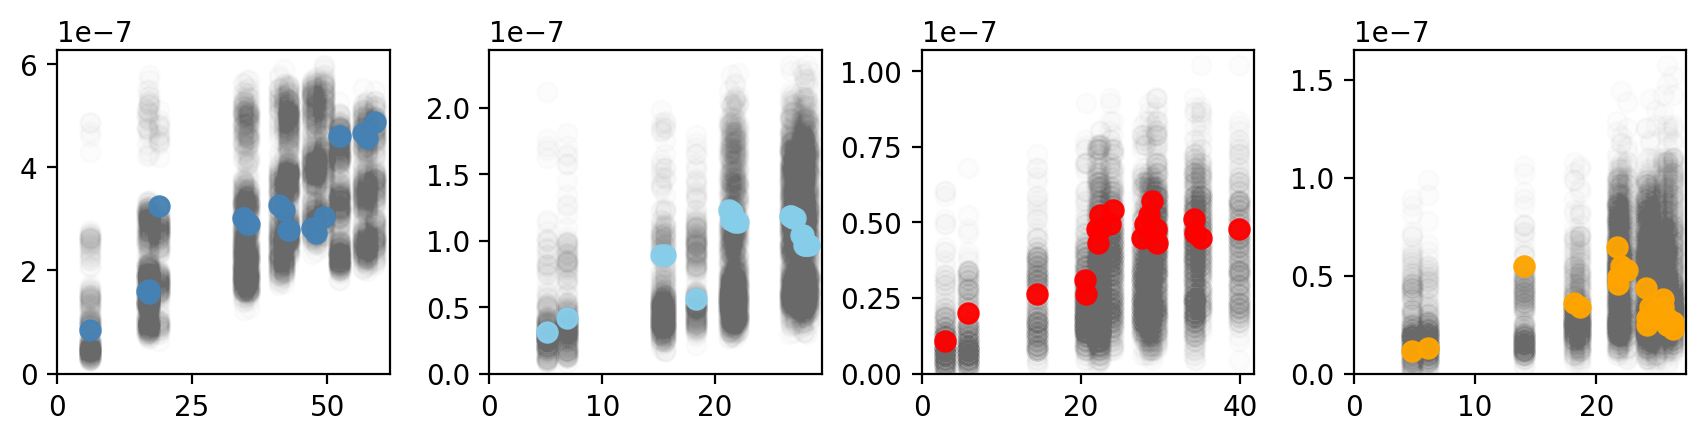

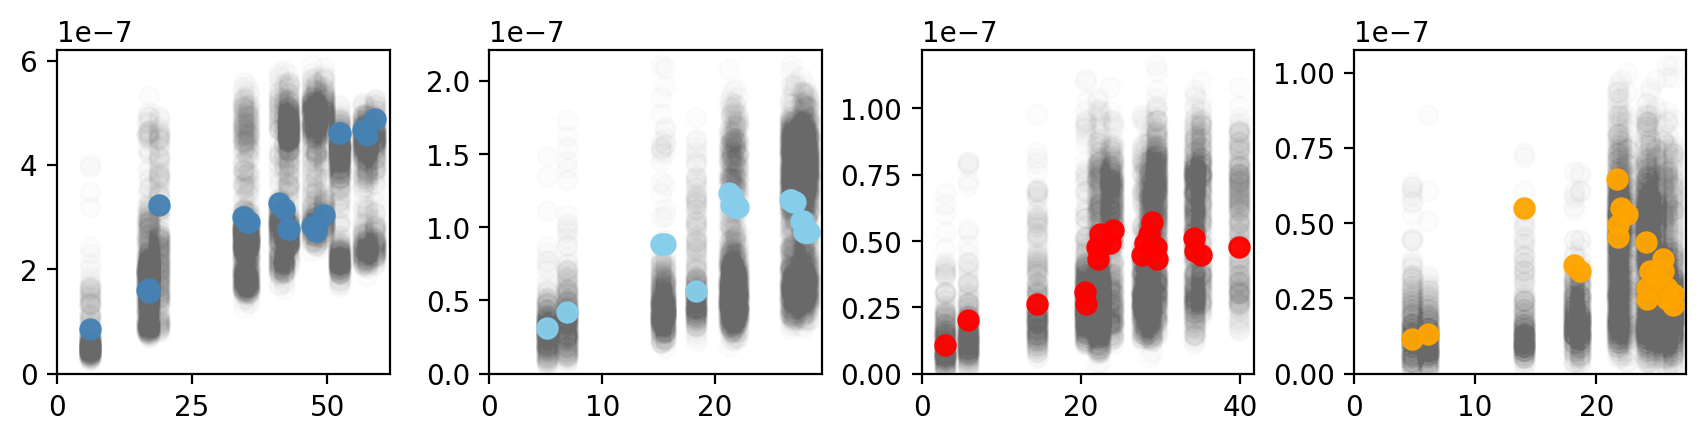

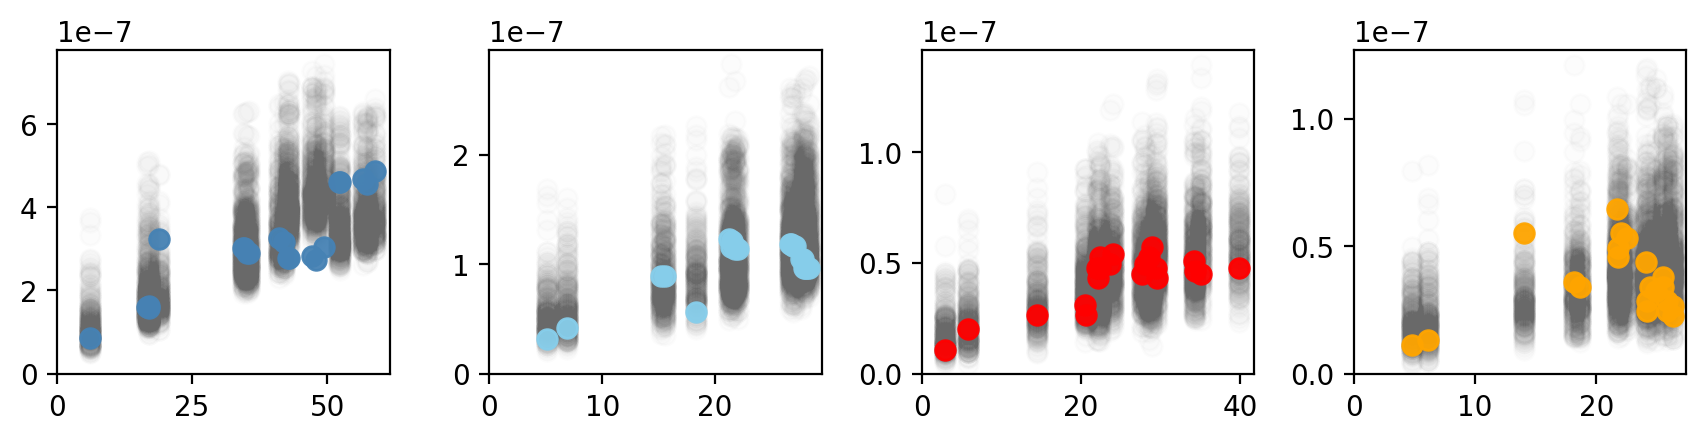

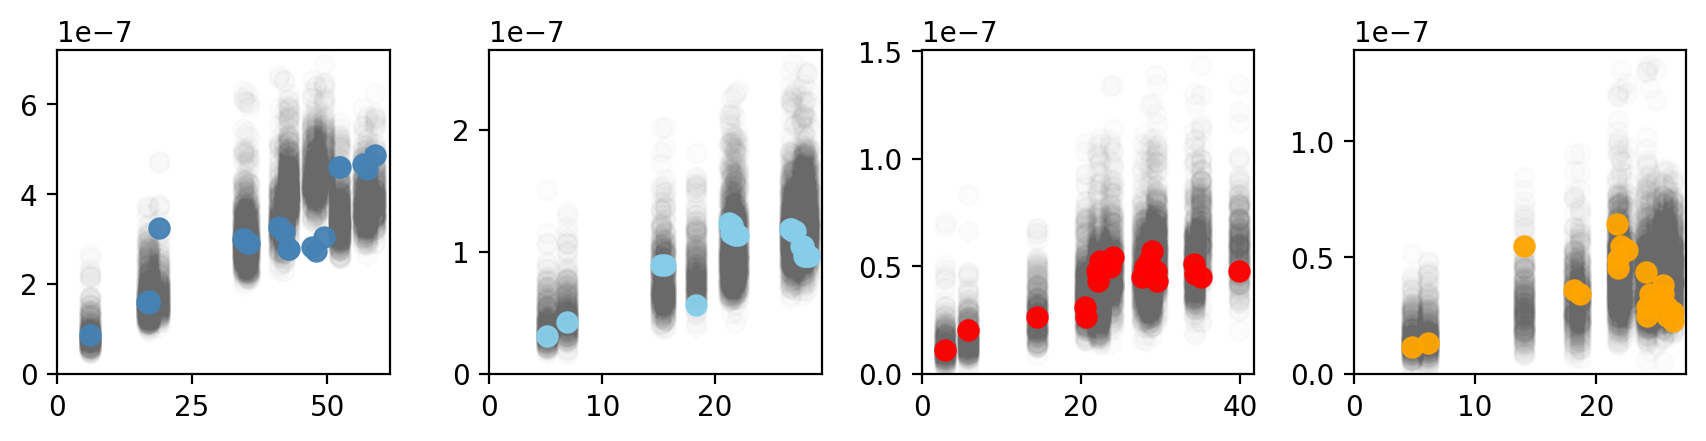

In [16]:
for ct_m, model in enumerate(['Model1.0', 'Model2.0', 'Model3.0', 'Model4.0']):
    
    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(3*3.50394, 0.6*3.50394), dpi=200) # 3.50394 inch = 89 mm (1 column)

    for ct_i, ind in enumerate(['S1', 'S2', 'F1', 'F2']):

        plt.subplot(1, 4, ct_i+1)
          
        # Paramters
        NumStem, _, div = model_paras[model+'_'+ind]
        gen_size, br_lens = ind_para_dict[ind]
        
        Num_mut_ibms = ibm_dist_AveHet_func(NumStem, sim_results[model+'_'+ind])
        br_Matrix = br_arch_func(br_lens)
        obs_ibm = ind_mut_data[ind]
        
        
        
        # Flattening physical distance between branches
        pre_mutCor_x = []
        for i in range(numBranch):
            for j in range(numBranch):
                if i<j:
                    pre_mutCor_x.append(br_Matrix[i][j])
        
        mutCor_x = np.array(pre_mutCor_x).flatten()
        
        # Simulation ---------------------------------------
        for ibm_m in Num_mut_ibms:
            numBranch = len(ibm_m) # number of branches
            
            # Flattening genetic distance between branches
            pre_mutCor_y = []
            for i in range(numBranch):
                for j in range(numBranch):
                    if i<j:
                        pre_mutCor_y.append(ibm_m[i][j]) 
                        
            mutCor_y = np.array(pre_mutCor_y).flatten()/gen_size # rescaling by dividing
            
            plt.scatter(mutCor_x, mutCor_y, s=50, marker='o', alpha=1/50, c='dimgrey')
        
        # Observation ---------------------------------------
        # Flattening genetic distance between branches
        plt.scatter(mutCor_x, obs_ibm, s=50, marker='o', alpha=.95, c=colordict[ind])
        
        # plt.title(ind)
        # plt.xlabel('Physical distance between branches (m)')
        # plt.ylabel('Number of inter-branch SNVs')
        plt.xlim(0,); plt.ylim(0,)

        plt.subplots_adjust(wspace=0.3)
        
    plt.show()

### Calculating MSE

In [18]:
colordict2 = {'Model1.0':'darkgreen', 'Model2.0':'olivedrab', 'Model3.0':'purple', 'Model4.0':'mediumpurple'}

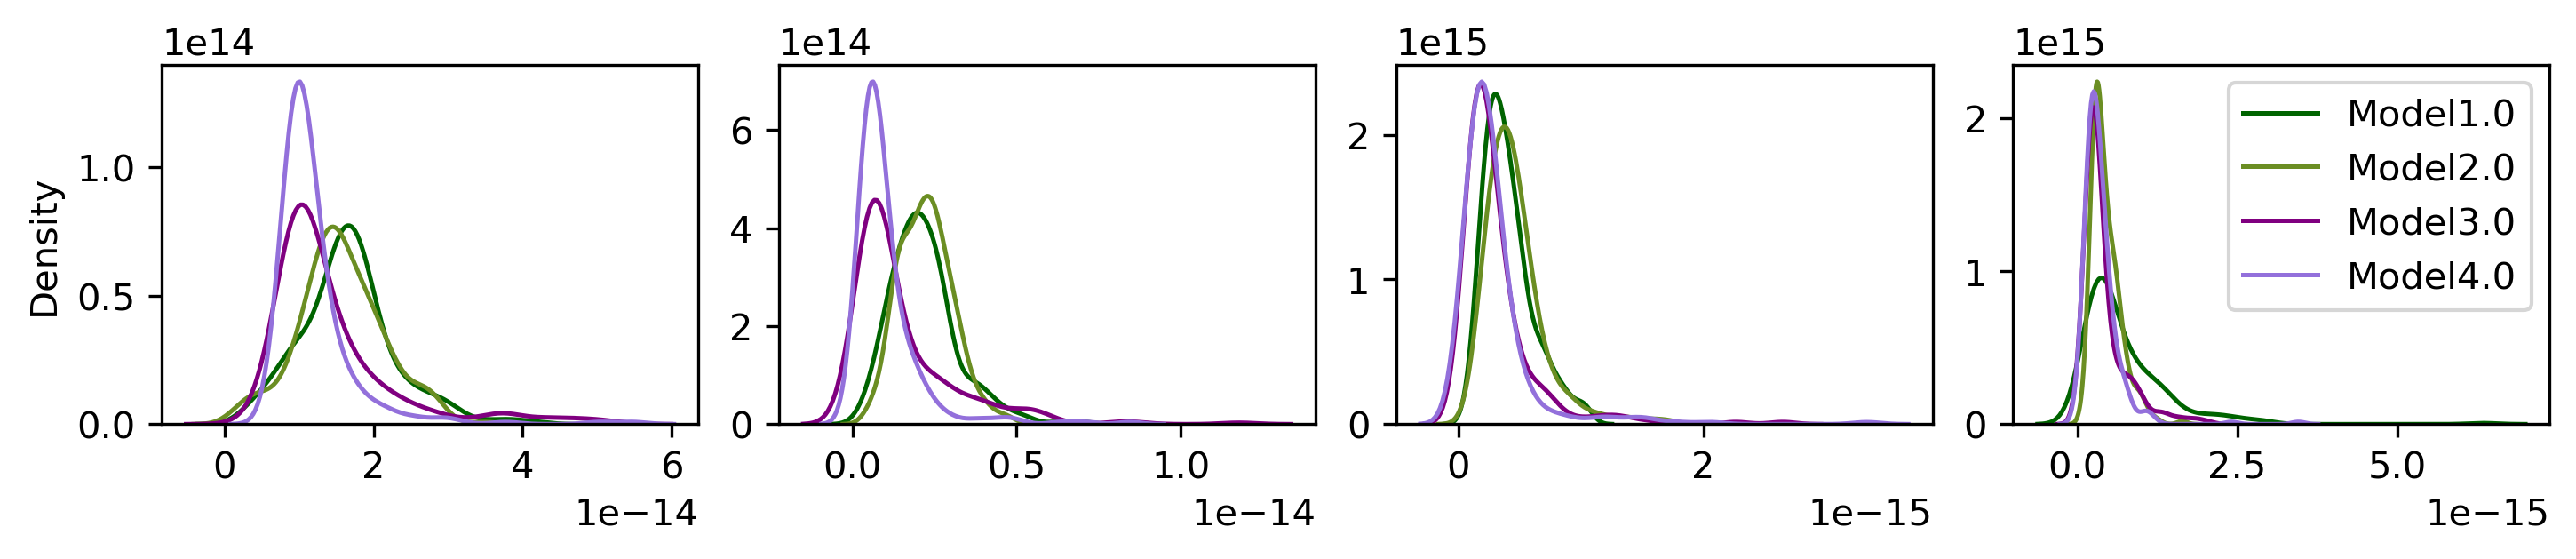

In [19]:
model = "Model4.0"
ind = "S1"

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(3.3*3.50394, 0.5*3.50394), dpi=300) # 3.50394 inch = 89 mm (1 column)

for ct_i, ind in enumerate(['S1', 'S2', 'F1', 'F2']):
    plt.subplot(1, 4, ct_i+1)
    for ct_m, model in enumerate(['Model1.0', 'Model2.0', 'Model3.0', 'Model4.0']):

        # Paramters -----------------------------------------------------------
        NumStem, _, div = model_paras[model+'_'+ind]
        gen_size, br_lens = ind_para_dict[ind]
        
        Num_mut_ibms = ibm_dist_AveHet_func(NumStem, sim_results[model+'_'+ind])
        br_Matrix = br_arch_func(br_lens)
        obs_ibm = ind_mut_data[ind]
        # ---------------------------------------------------------------------
        
        # Observation ---------------------------------------------------------
        observation = ind_mut_data[ind]
        
        # Simulation ---------------------------------------
        mse_list = [] # for calculating distributions
        
        for ibm_m in Num_mut_ibms:
            numBranch = len(ibm_m) # number of branches
            
            # Flattening genetic distance between branches from model prediction
            pre_prediction = []
            for i in range(numBranch):
                for j in range(numBranch):
                    if i<j:
                        pre_prediction.append(ibm_m[i][j])
                        
            prediction = np.array(pre_prediction).flatten()/gen_size
        
            # Calculating MSE
            sq_err = (prediction - observation)**2
            mse = np.mean(sq_err)
            mse_list.append(mse)

        # Plotting -------------------------------------------------------------
        sns.kdeplot(mse_list, fill=False, lw=1.2, color=colordict2[model], label=model, ax=ax[ct_i])
        if ct_i > 0:
            ax[ct_i].set_ylabel("")

plt.subplots_adjust(wspace=0.15)
plt.legend()
plt.show()

### Topological congruence

In [22]:
import numpy as np
from scipy.cluster.hierarchy import linkage, to_tree
from scipy.spatial.distance import squareform
import dendropy
from dendropy.calculate import treecompare

In [23]:
# --- Func to change into Newick format ---
def linkage_to_newick(Z, labels):
    tree = to_tree(Z)
    def build_newick(node):
        if node.is_leaf():
            return labels[node.id]
        else:
            left = build_newick(node.get_left())
            right = build_newick(node.get_right())
            return f"({left},{right})"
    return build_newick(tree) + ";"

In [24]:
# Ratio: Comparing physical and genetic trees

for ct_m, model in enumerate(['Model1.0', 'Model2.0', 'Model3.0', 'Model4.0']):
    for ct_i, ind in enumerate(['S1', 'S2', 'F1', 'F2']):
        
        # Paramters -----------------------------------------------------------
        NumStem, _, div = model_paras[model+'_'+ind]
        gen_size, br_lens = ind_para_dict[ind]
        
        Num_mut_ibms = ibm_dist_AveHet_func(NumStem, sim_results[model+'_'+ind])
        br_Matrix = br_arch_func(br_lens)
        obs_ibm = ind_mut_data[ind]
        # ---------------------------------------------------------------------
        
        Z_phys_dist = linkage(squareform(br_Matrix),  # physical distances between branches
                             method='average')  # UPGMA
        
        # --- Constructing physical tree ---
        newick_phys = linkage_to_newick(Z_phys_dist, br_ID)  # br_ID gives labels of branches
        tns = dendropy.TaxonNamespace(br_ID) # making common TaxonNamespace (needed to work well)
        
        tree_phys = dendropy.Tree.get(
            data=newick_phys,
            schema="newick",
            taxon_namespace=tns
        )
        
        # --- Comparing with simulation results ------
        same_topology_count = 0
        rf_list = []
        
        for mut_ibms in Num_mut_ibms:
        
            mut_ibms = (mut_ibms + mut_ibms.T)/2 # diagonalize to meet linkage() requirements
        
            # tree construction by UPGMA
            Z_gen_dist = linkage(squareform(mut_ibms), method='average')
            newick_gen = linkage_to_newick(Z_gen_dist, br_ID)
            
            # making tree by dendropy
            tree_gen = dendropy.Tree.get(
                data=newick_gen,
                schema="newick",
                taxon_namespace=tns # the common TaxonNamespace
            )
        
            # Topology comparison by Robinson-Foulds distance
            rf = treecompare.unweighted_robinson_foulds_distance(tree_phys, tree_gen)
            if rf == 0: # topologies are identical
                same_topology_count += 1
        
        # Ratio of congruence -------------------------------------
        match_ratio = same_topology_count / len(Num_mut_ibms)
        print("="*2+' '+model+', '+ind+' '+"="*5)
        print(f"Congruence count: {same_topology_count} / {len(Num_mut_ibms)}")
        print(f"Congruence rate: {match_ratio:.3f}")

== Model1.0, S1 =====
Congruence count: 120 / 250
Congruence rate: 0.480
== Model1.0, S2 =====
Congruence count: 78 / 250
Congruence rate: 0.312
== Model1.0, F1 =====
Congruence count: 54 / 250
Congruence rate: 0.216
== Model1.0, F2 =====
Congruence count: 58 / 250
Congruence rate: 0.232
== Model2.0, S1 =====
Congruence count: 110 / 250
Congruence rate: 0.440
== Model2.0, S2 =====
Congruence count: 71 / 250
Congruence rate: 0.284
== Model2.0, F1 =====
Congruence count: 55 / 250
Congruence rate: 0.220
== Model2.0, F2 =====
Congruence count: 36 / 250
Congruence rate: 0.144
== Model3.0, S1 =====
Congruence count: 176 / 250
Congruence rate: 0.704
== Model3.0, S2 =====
Congruence count: 87 / 250
Congruence rate: 0.348
== Model3.0, F1 =====
Congruence count: 105 / 250
Congruence rate: 0.420
== Model3.0, F2 =====
Congruence count: 57 / 250
Congruence rate: 0.228
== Model4.0, S1 =====
Congruence count: 219 / 250
Congruence rate: 0.876
== Model4.0, S2 =====
Congruence count: 137 / 250
Congruenc

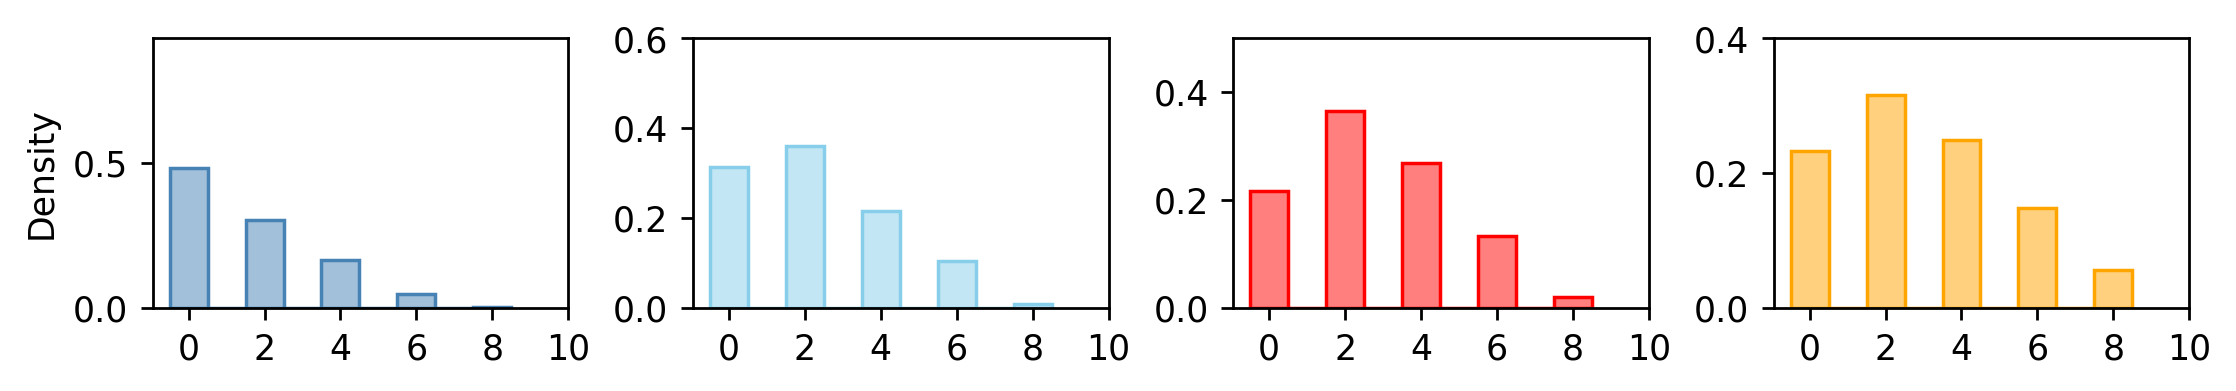

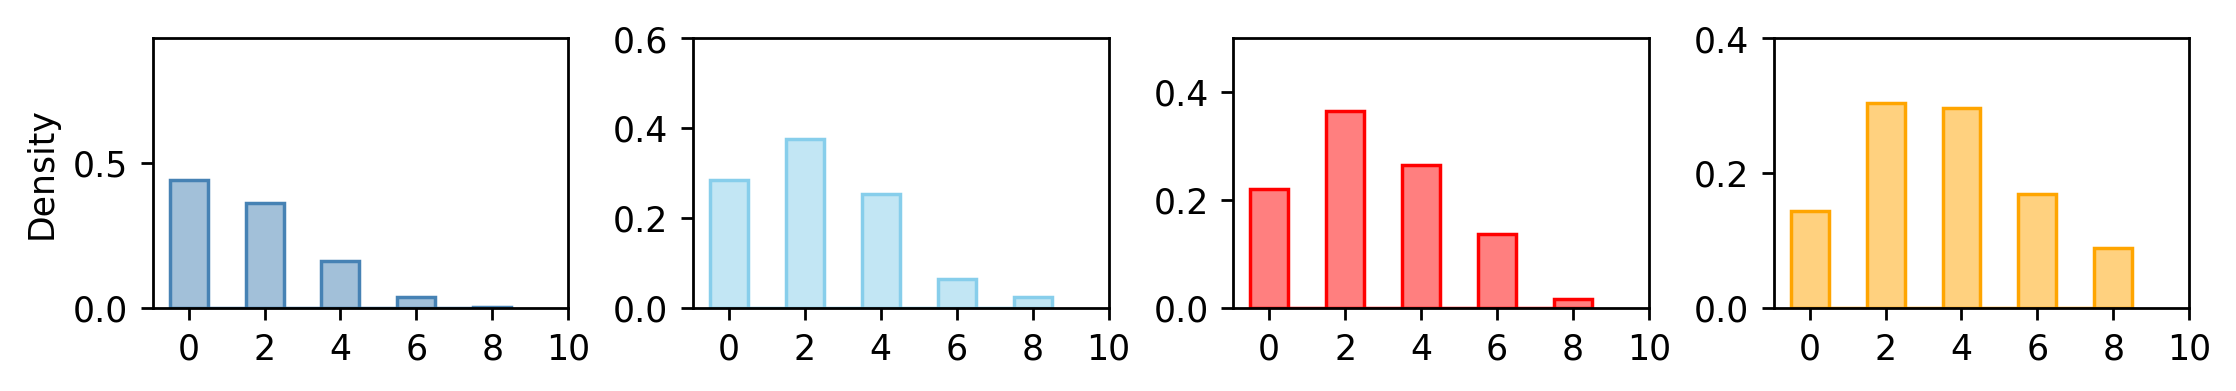

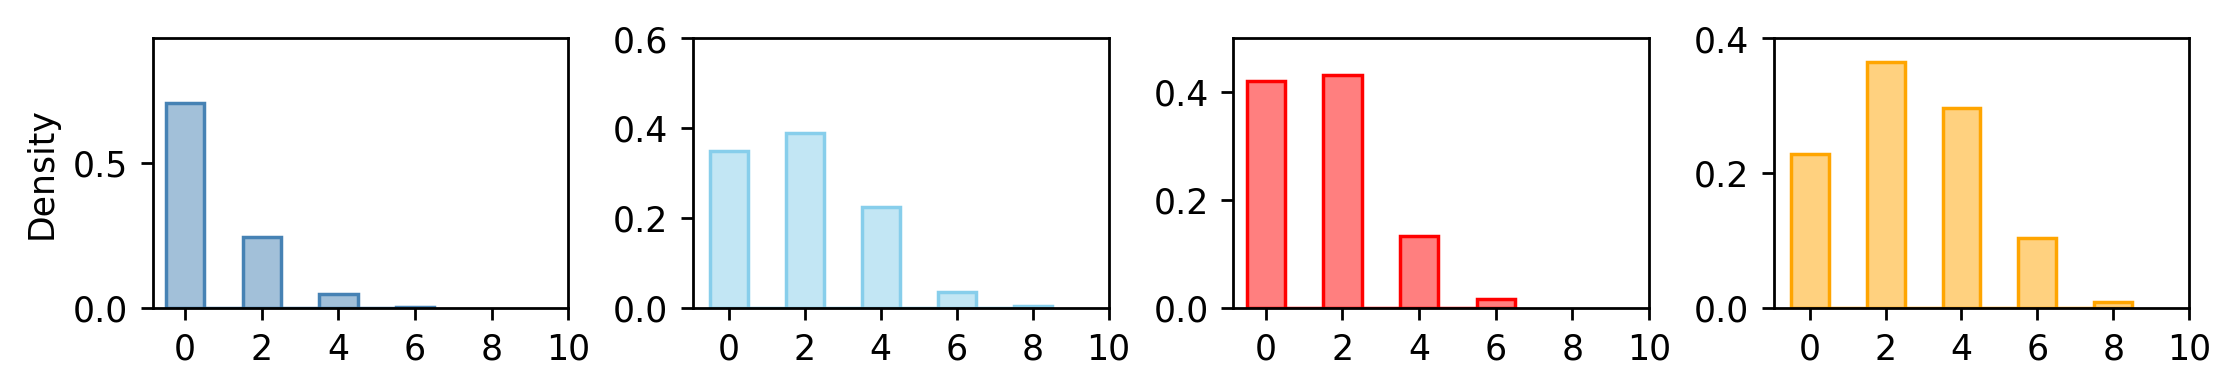

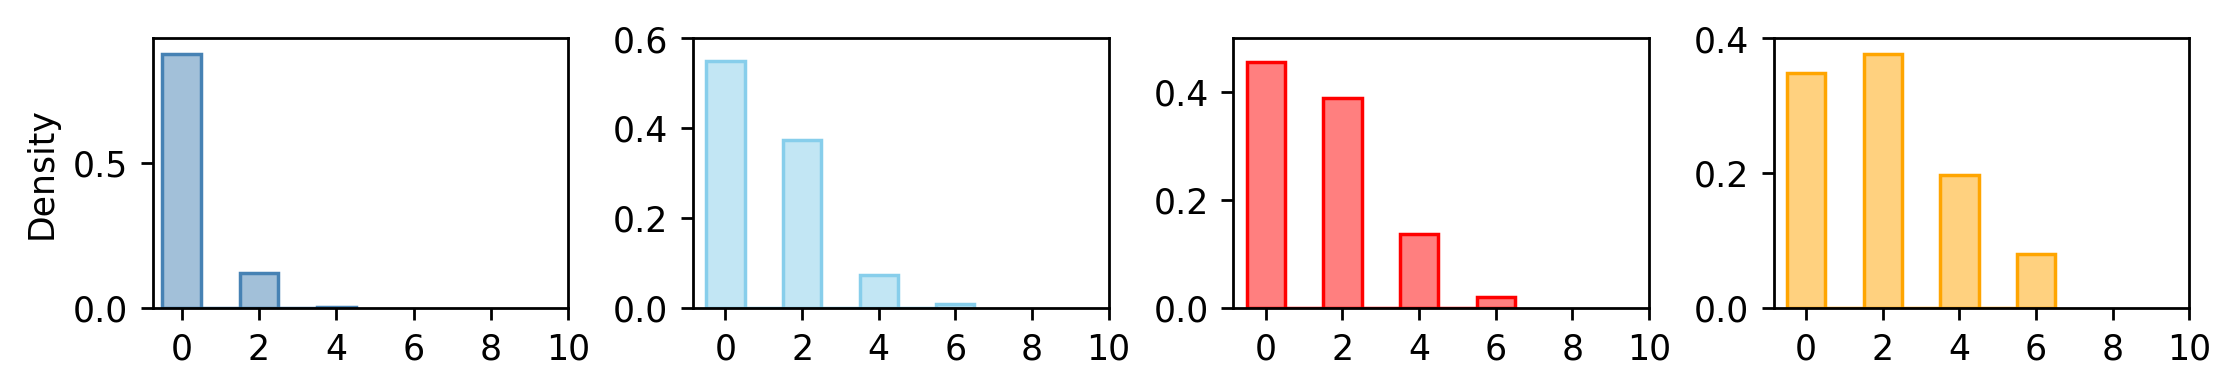

In [28]:
# Plotting: Comparing physical and genetic trees
ylim_dict3 = {'S1':.93, 'S2':.6, 'F1':.5, 'F2':.4}

for ct_m, model in enumerate(['Model1.0', 'Model2.0', 'Model3.0', 'Model4.0']):
    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(3*3.50394, 0.4*3.50394), dpi=250) # 3.50394 inch = 89 mm (1 column)

    for ct_i, ind in enumerate(['S1', 'S2', 'F1', 'F2']):

        plt.subplot(1, 4, ct_i+1)
        
        # Paramters -----------------------------------------------------------
        NumStem, _, div = model_paras[model+'_'+ind]
        gen_size, br_lens = ind_para_dict[ind]
        
        Num_mut_ibms = ibm_dist_AveHet_func(NumStem, sim_results[model+'_'+ind])
        br_Matrix = br_arch_func(br_lens)
        obs_ibm = ind_mut_data[ind]
        # ---------------------------------------------------------------------
        
        Z_phys_dist = linkage(squareform(br_Matrix),  # physical distances between branches
                             method='average')  # UPGMA
        
        # --- Constructing physical tree ---
        newick_phys = linkage_to_newick(Z_phys_dist, br_ID)  # br_ID gives labels of branches
        tns = dendropy.TaxonNamespace(br_ID) # making common TaxonNamespace (needed to work well)
        
        tree_phys = dendropy.Tree.get(
            data=newick_phys,
            schema="newick",
            taxon_namespace=tns
        )
        
        # --- Comparing with simulation results ------
        same_topology_count = 0
        rf_list = []
        
        for mut_ibms in Num_mut_ibms:
        
            mut_ibms = (mut_ibms + mut_ibms.T)/2 # diagonalize to meet linkage() requirements
        
            # tree construction by UPGMA
            Z_gen_dist = linkage(squareform(mut_ibms), method='average')
            newick_gen = linkage_to_newick(Z_gen_dist, br_ID)
            
            # making tree by dendropy
            tree_gen = dendropy.Tree.get(
                data=newick_gen,
                schema="newick",
                taxon_namespace=tns # the common TaxonNamespace
            )
        
            # Topology comparison by Robinson-Foulds distance
            rf = treecompare.unweighted_robinson_foulds_distance(tree_phys, tree_gen)
            rf_list.append(rf)
        
        # Plotting ------------------------------------------------
        sns.histplot(rf_list, kde=False, stat="density",
            binwidth=1,                     # ← ここが重要
            binrange=(min(rf_list)-0.5, max(rf_list)+0.5),
            color=colordict[ind], edgecolor=colordict[ind], alpha=0.5,
            ax=ax[ct_i]
        )
        plt.ylim(0, ylim_dict3[ind])
        plt.xticks(range(int(min(rf_list)), 10+1, 2))
        if ct_i > 0:
            ax[ct_i].set_ylabel("")

    plt.subplots_adjust(wspace=0.3) 
    plt.show()

### Distribution patterns of somatic SNVs

In [14]:
# For observation data from Satake et al 2024 eLife

ind_mut_dist = {} # for saving mutation matrix

# Generating possible patterns
numBranch=7
mutShapeTemplate = np.array(list(itertools.product([0,1],repeat=numBranch))) # patters of mutation distribution (all possible patterns)

# Template for distribution patterns
mutShapeTemplate_0 = [[i,0] for i in mutShapeTemplate.tolist()]
mutShapeTemplate_0_sort_key = sorted(mutShapeTemplate_0, key=lambda x: sum(x[0])) # sort by template

# Calculation
for ind in ['S1', 'S2', 'F1', 'F2']:

    # Reading data and Converting to mutation matrices -------------------
    # loading data
    if ind == 'S1':
        path_id = 'Slaevis_ID1'
    elif ind == 'S2':
        path_id = 'Slaevis_ID2'
    elif ind == 'F1':
        path_id = 'Sleprosula_ID1'
    elif ind == 'F2':
        path_id = 'Sleprosula_ID2'
      
    with open('/Users/soutomimoto/Desktop/mathbio2019/apical_meristem_IV/data/'+ path_id +'_1209.csv') as pre_data_tree:
        reader = csv.reader(pre_data_tree)
        data_tree = [row for row in reader]
    
    # converting to mutation matrix
    mut_M = []
    count_homo = 0
    for i in data_tree[1:]: # eliminating column names
        
        if ('0/0' in i)and('1/1' in i):# eliminating homo to homo mutation
            #print(i)
            count_homo+=1
            
        else:
            row_M = []
            for j in i[1:]:
                if j != i[0]: # different from branch 0
                    row_M.append(1)
                elif j == i[0]: # same with branch 0
                    row_M.append(0)
            mut_M.append(copy.copy(row_M))
    
    mut_M = np.array(mut_M)
    
    # Calculating observed distribution patterns ---------------------------
    
    # Counting the number of mutations corresponding to each expansion pattern
    mutShapeMatrix = [0 for i in range(2**numBranch)]
    for icut,i in enumerate(mutShapeTemplate): 
        for k in range(len(mut_M)): 
            if np.all(mut_M[k] ==i): # shorting the mutation which fit to the template (certain pattern)
                mutShapeMatrix[icut] = mutShapeMatrix[icut] + 1
    
    allMutDist = np.array(mutShapeMatrix) #　distribution of mutation expansion which corresponding to the template
    
    #sort
    # mutDist_TemList=[]; mutDist_TemList_sort_value = []; mutDist_TemList_sort_key = []
    
    mutDist_TemList = [[i,j] for i,j in zip(mutShapeTemplate.tolist(), allMutDist)] # zipping (pattern, number of mutation)
    # mutDist_TemList_sort_value = sorted(mutDist_TemList, key=lambda x: x[1], reverse=True) # sorting by the number
    mutDist_TemList_sort_key = sorted(mutDist_TemList, key=lambda x: sum(x[0])) # sorting by the number of expanded branches

    ind_mut_dist[ind] = mutDist_TemList_sort_key

In [15]:
# Eliminating non-observed patterns
ind_keySet_obs = {}
ind_mut_dist_obs = {}

for ind in ['S1', 'S2', 'F1', 'F2']:
    keySet_obs = []
    mutDist_TemList_sort_key_short = []
    
    for i in ind_mut_dist[ind]:
        if i[1] >= 1: # eliminating non-observed patterns (i.e., i[1]==0)
            keySet_obs.append(i[0])
            mutDist_TemList_sort_key_short.append(i)

    ind_keySet_obs[ind] = keySet_obs
    ind_mut_dist_obs[ind] = mutDist_TemList_sort_key_short

In [16]:
# Func for calculating the distribution pattern of somatic mutations

def mut_dist_func(NumStem, resultList_2): 
    
    numBranch = np.array(resultList_2[0]).shape[0]
    mutShapeTemplate = np.array(list(itertools.product([0,1],repeat=numBranch)))

    # The pattern of expansion of somatic mutations
    
    # NumAveallMutDist = []
    # NumAveSDallMutDist = [] #for SD
    # NumAveallMutFreqDist = [] #freq

    NumTime = len(resultList_2)
    for num_time in range(NumTime):

        br_brmutMatrix = resultList_2[num_time]
        
        # The distribution pattern of somatic mutations, focusing on mutations at the tip of branches
        mutShapeMatrix = [0 for i in range(2**numBranch)]
        # br_brmut01Matrix = np.nan_to_num(br_brmutMatrix/br_brmutMatrix) #convert to 01 (changing Nan, resulting from 0/0, into 0） row:branch, colum:mutation
        br_brmut01Matrix = (br_brmutMatrix != 0).astype(int) # convert to 1/0 (presence/absence)

        for icut,i in enumerate(mutShapeTemplate): # mutShapeTemplate is a list for all possible combinations
            for k in range(len(br_brmutMatrix[0])):
                if np.all(br_brmut01Matrix[:,k] ==i):
                    mutShapeMatrix[icut] = mutShapeMatrix[icut] + 1

        if num_time==0: 
            allMutDist = np.array(mutShapeMatrix)
            totalMutDist = [mutShapeMatrix] #for SD
        else:           
            allMutDist = allMutDist + np.array(mutShapeMatrix)
            totalMutDist.append(mutShapeMatrix) #for SD
        

        # The distribution pattern of somatic mutations
        # freq_(枝末端間の変異細胞数の average)
        mutShapeFreqMatrix = [[0 for i in range(sum(j)*NumStem)] for j in mutShapeTemplate] # [] for different Ave_mutations, sum(j)*NumStem:number of average variationn

        for icut,i in enumerate(mutShapeTemplate): # mutShapeTemplate is a list for all possible combinations
            for j in br_brmutMatrix.T:
                if sum(j)!=0 and np.all(np.nan_to_num(j/j) == i):# eliminate [0,0,...,0] all 0 list
                    mutShapeFreqMatrix[icut][sum(j)-1] += 1 # sum(j);sum of mutated cells, sum(j)-1; index of list

        if num_time==0:
            allMutFreqDist = copy.deepcopy(mutShapeFreqMatrix)
        else:
            for icut,i in enumerate(copy.deepcopy(mutShapeFreqMatrix)):
                for jcut,j in enumerate(i):
                    allMutFreqDist[icut][jcut] += j

    # Distribution of mutations
    AveallMutDist = allMutDist/NumTime # The pattern of expansion of somatic mutations
    # NumAveallMutDist.append(AveallMutDist) # for different NumStem
    
    # Standered deviation of dist
    sumtotalMutDist = np.array([float(0) for _ in mutShapeTemplate])
    for k in  totalMutDist:
        sumtotalMutDist += (np.array(k)-AveallMutDist)**2 # for each branch
    # NumAveSDallMutDist.append((sumtotalMutDist/len(totalMutDist))**(1/2)) # Standered deviation for each branches
    SDallMutDist = (sumtotalMutDist/len(totalMutDist))**(1/2) # Standered deviation for each branches

    #freq_pattern_Distribution of mutations
    AveallMutFreqDist = [[i/NumTime for i in j] for j in allMutFreqDist] # The pattern of expansion of somatic mutations with freq
    # NumAveallMutFreqDist.append(AveallMutFreqDist)
        
    return AveallMutFreqDist, SDallMutDist # NumAveallMutFreqDist, NumAveSDallMutDist

In [31]:
threshold = .5 # to remove patterns with expectation < threshold

In [32]:
# Sorting by patterns

# threshold = .25 # to remove patterns with expectation < threshold

all_mut_dist_pred = {} # for patterns
all_keySet_pred = {}   # for keys

for model in ['Model1.0', 'Model2.0', 'Model3.0', 'Model4.0']:
    for ind in ['S1', 'S2', 'F1', 'F2']:
        
        # if ind == 'S1' or 'S2':
        #     threshold = 1 # to remove patterns with expectation < threshold
        # elif ind == 'F1' or 'F2':
        #     threshold = .5
        
        # Calculating pred ---------------------------------------------------------------
        NumStem, _, _ = model_paras[model+'_'+ind]
        AveallMutFreqDist, _ = mut_dist_func(NumStem, sim_results[model+'_'+ind])
        
        mutDist_TemFreqList = [[i,j] for i,j in zip(mutShapeTemplate.tolist(), AveallMutFreqDist)]
        mutDist_TemFreqList_sort_key = sorted(mutDist_TemFreqList, key=lambda x: sum(x[0])) # sort by template
        
        mutDist_TemFreqList_sort_key_short = [i for i in mutDist_TemFreqList_sort_key if sum(i[1])>=threshold] # removing mutation with freq < threshold
        
        all_mut_dist_pred[model+'_'+ind] = mutDist_TemFreqList_sort_key_short

        # For Keys -----------------------------------------------------------------------
        keySet = []
        for i in mutDist_TemFreqList_sort_key_short:
            keySet.append(i[0])
        
        all_keySet_pred[model+'_'+ind] = keySet
        # ---------------------------------------------------------------------------------

/var/folders/mw/8q3jgtp14fx55g11sttt1t3m0000gn/T/ipykernel_84424/1570146465.py:43: RuntimeWarning: invalid value encountered in divide
  if sum(j)!=0 and np.all(np.nan_to_num(j/j) == i):# eliminate [0,0,...,0] all 0 list


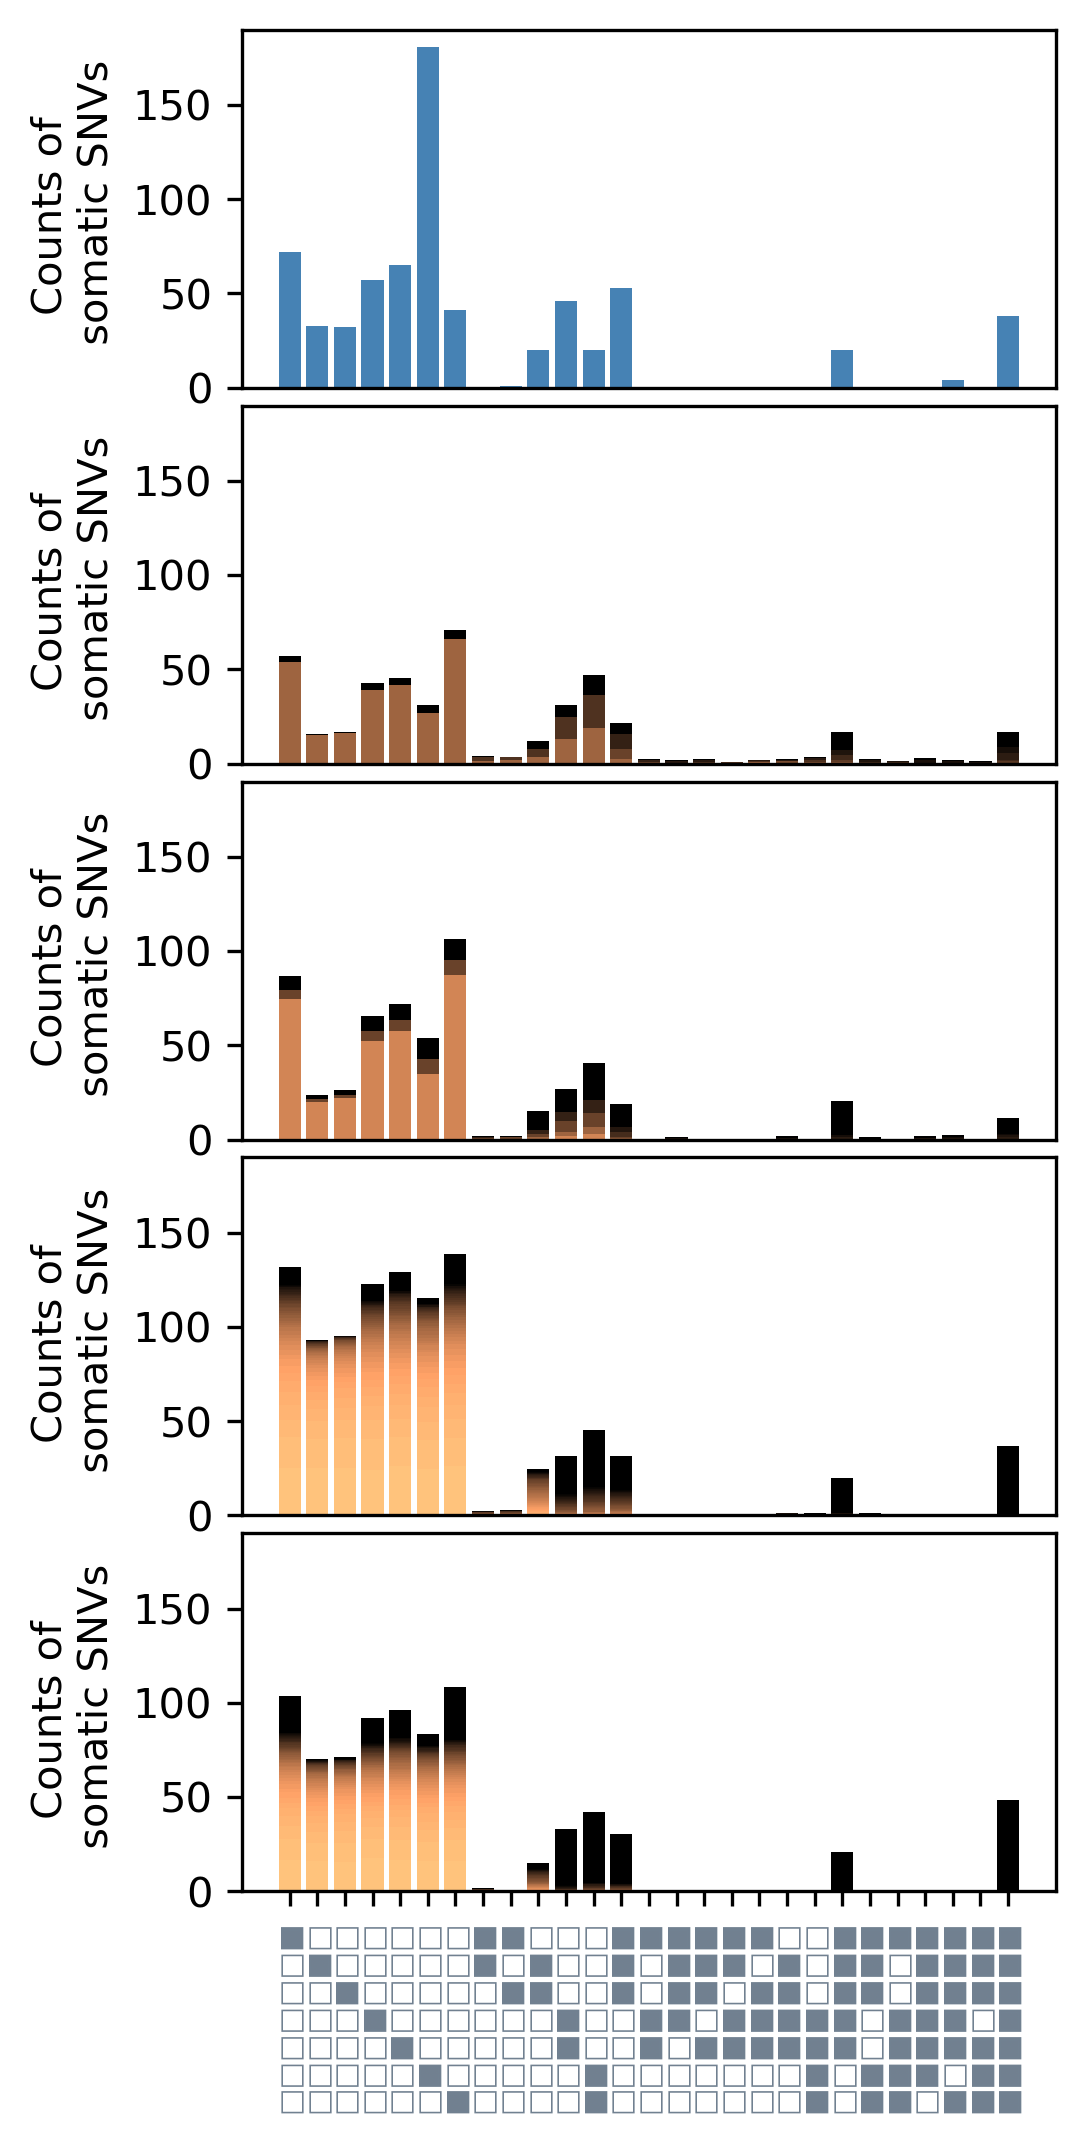

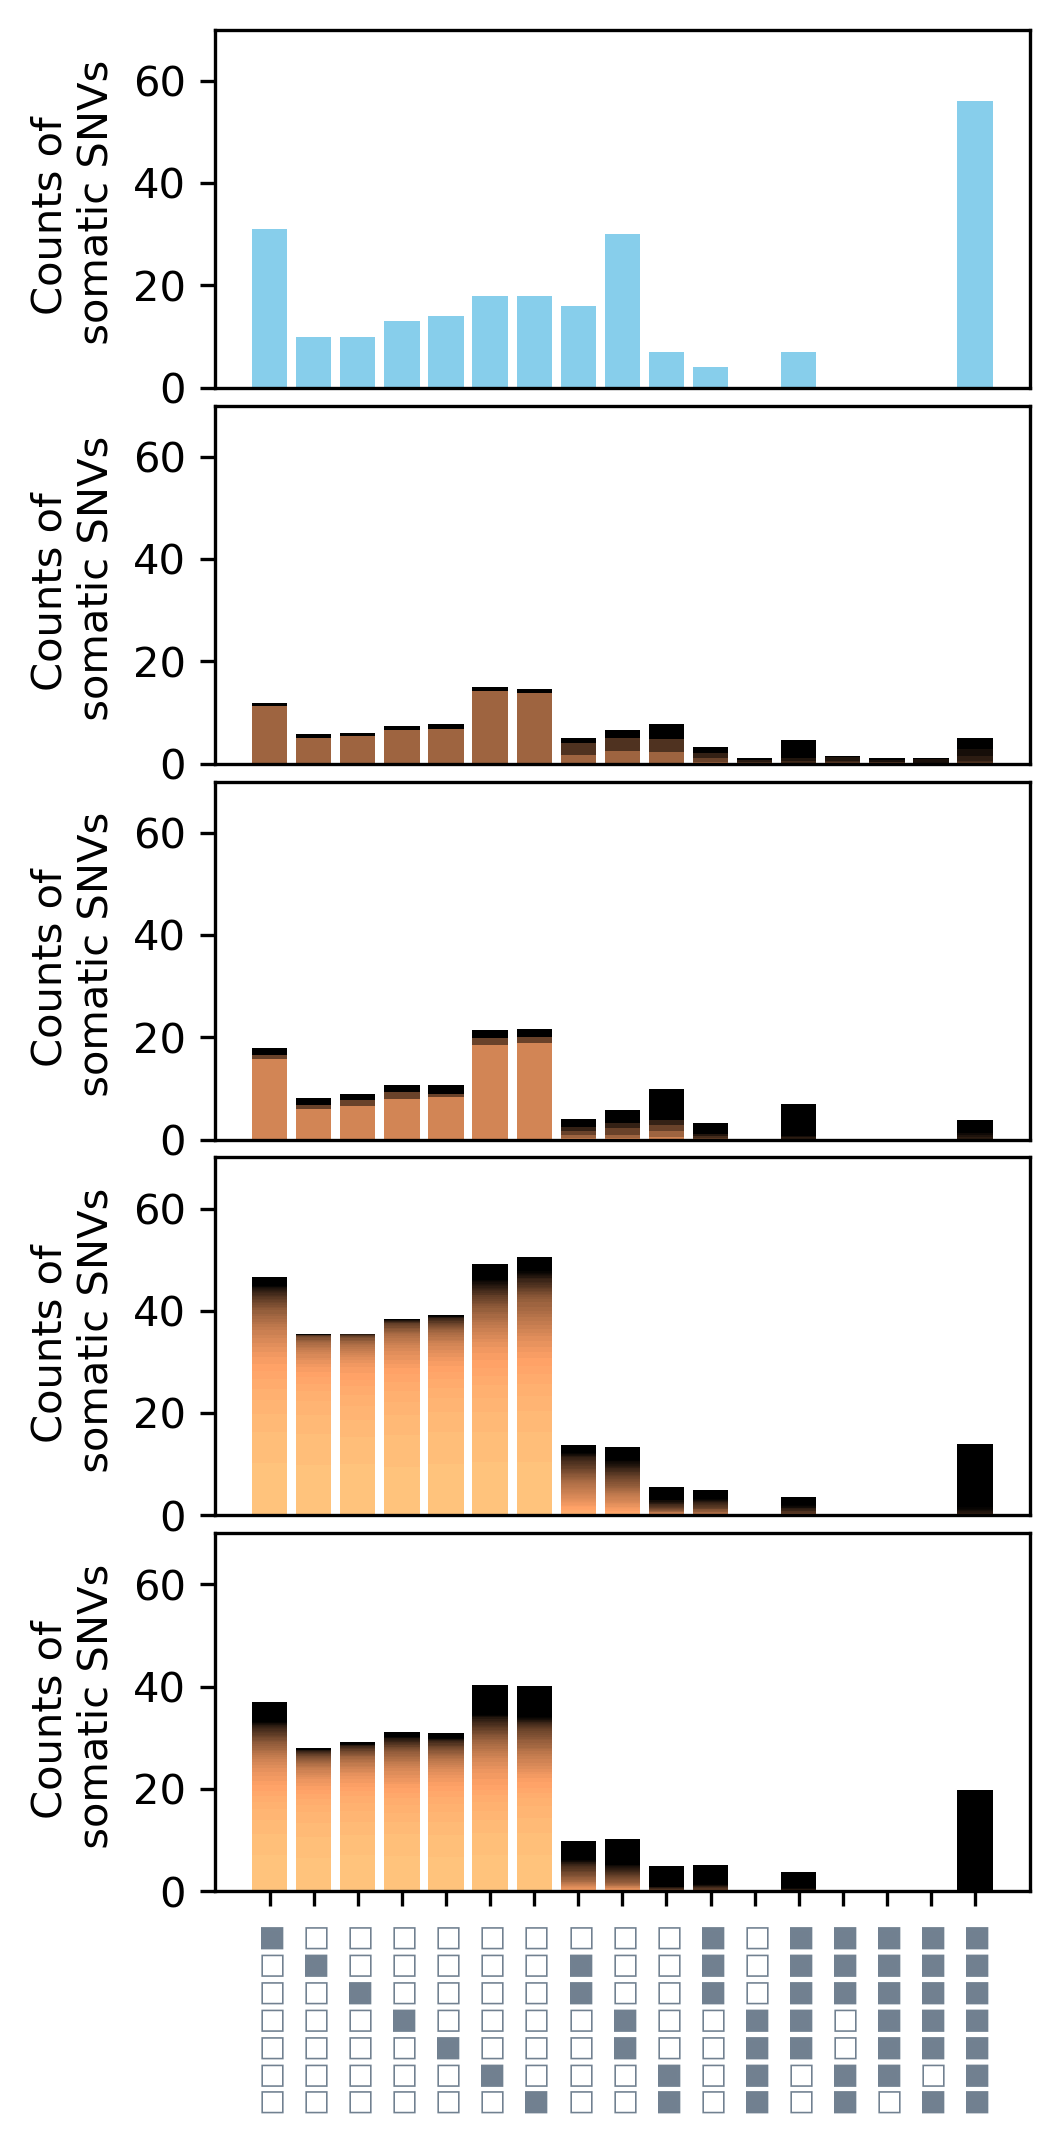

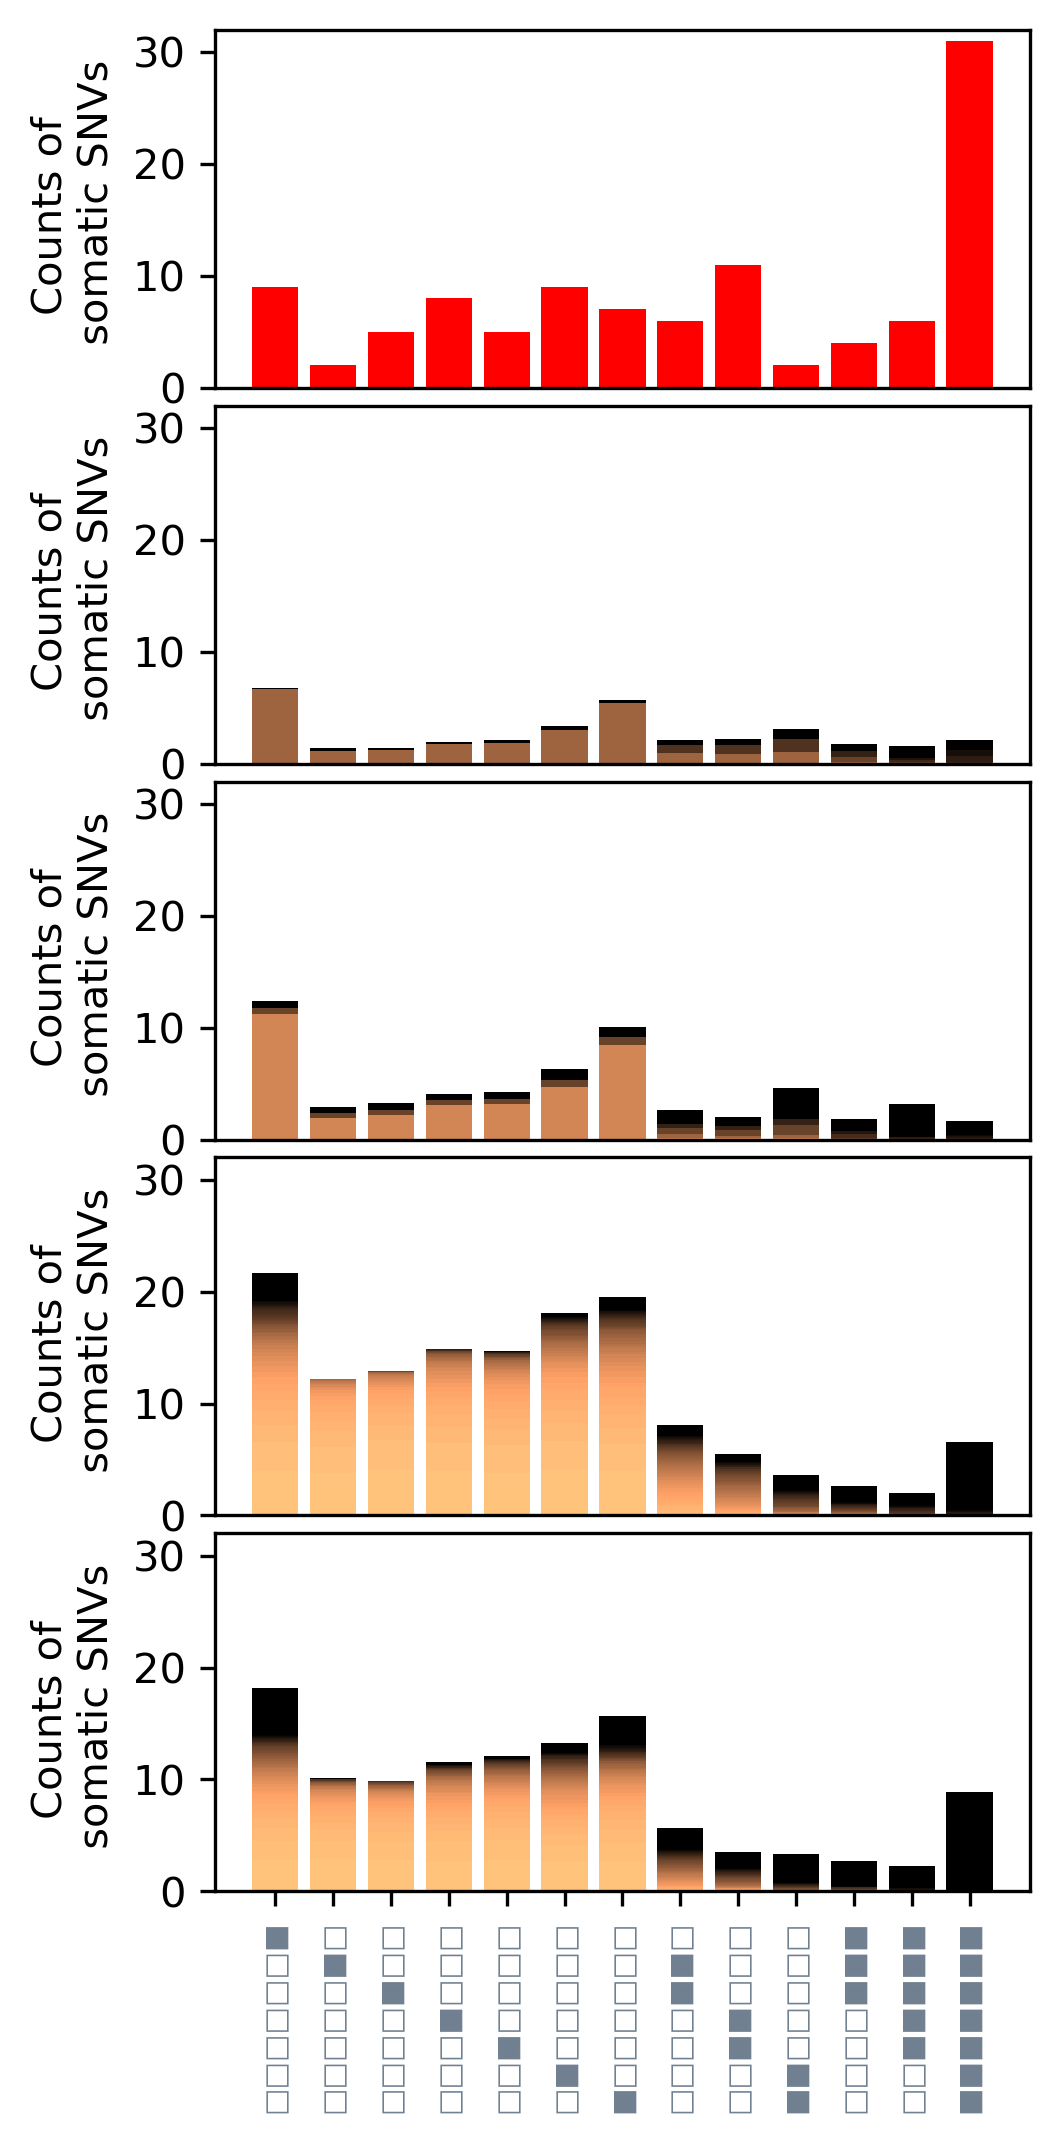

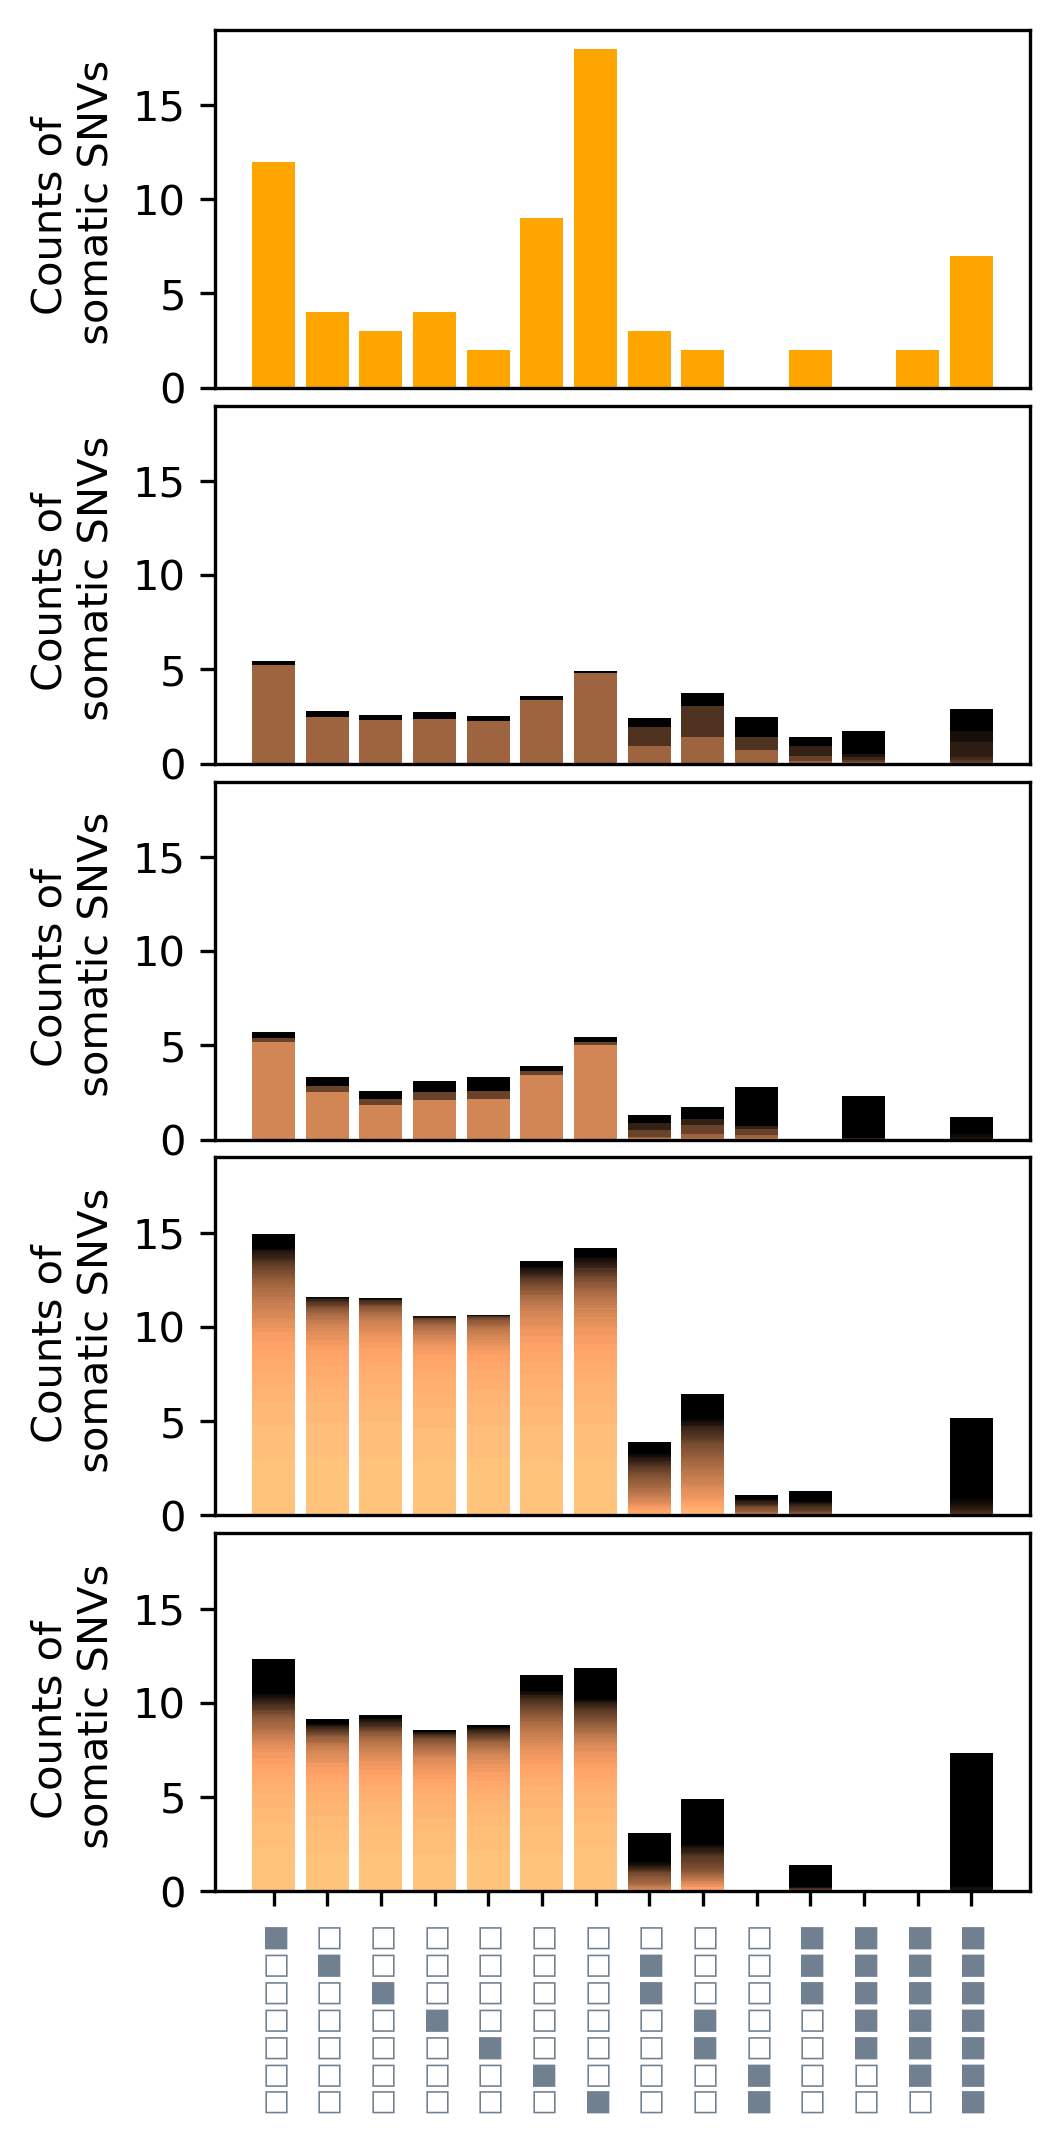

In [28]:
# Plotting
ylim_dict = {'S1':190, 'S2':70, 'F1':32, 'F2':19}

for ind in ['S1', 'S2', 'F1', 'F2']:
    
    fig, ax = plt.subplots(5, 1, figsize=(3.50394, 3.50394*2.3), dpi=300)
    
    # Keys for ind ----------------------------------------
    keys_all = ind_keySet_obs[ind]
    for md in ['Model1.0', 'Model2.0', 'Model3.0', 'Model4.0']:
        keys_all = keys_all + all_keySet_pred[md+'_'+ind]

    keyList = [list(i[0]) for i in mutShapeTemplate_0_sort_key if i[0] in keys_all]
    
    # Labels; patterns vector -> □ ■
    pre_dist_labels = [['□' if k==0 else '■' for k in i] for i in keyList] # mutDist_TemList_sort_key
    dist_labels = [''.join(j) for j in pre_dist_labels]

    # Observation re-calculation --------------------------
    dataList = []
    for i in keyList:
        ct_d = 0
        for j in ind_mut_dist_obs[ind]:
            if i == j[0]:
                dataList.append([i, j[1]])
                ct_d += 1
        if ct_d == 0:
            dataList.append([i, 0])

    # Plotting observation --------------------------------
    plt.subplot(5, 1, 1)
    for kcut,k in enumerate(dataList):
        for l in range(numBranch+1):# to change color by bar graf 
            if sum(k[0])==l:
                plt.bar(kcut,k[1], color=colordict[ind]) # "darkorange", "sandybrown"

    # Writing pattern on x_axis(xtrick)
    plt.xticks([])
    plt.ylabel('Counts of \n somatic SNVs', fontsize = 10)
    plt.tick_params(axis='y', which='major', labelsize=10)
    plt.ylim(0,ylim_dict[ind])
    # -----------------------------------------------------

    # For model predictions
    for ct_m, model in enumerate(['Model1.0', 'Model2.0', 'Model3.0', 'Model4.0']):

        # Parameters
        NumStem, _, _ = model_paras[model+'_'+ind]
        # Predictions
        predList = []
        for i in keyList:
            ct_p = 0
            for j in all_mut_dist_pred[model+'_'+ind]:
                if i == j[0]:
                    predList.append([i, j[1]])
                    ct_p += 1
            if ct_p == 0:
                predList.append([i, [0]])
        
        # Plotting simulation --------------------------
        plt.subplot(5, 1, ct_m+2)
        for kcut,k in enumerate(predList):
            bottom_data = 0 # for plot
            for lcut,l in enumerate(k[1]):
                plt.bar(kcut,l,bottom=bottom_data, color=cm.copper(1-(lcut+1)/(NumStem*sum(k[0]))))
                
                bottom_data += l
        
        # writing pattern on x_axis (xtrick)
        if ct_m < 3:
            plt.xticks([])
            plt.ylabel('Counts of \n somatic SNVs', fontsize = 10)
            plt.tick_params(axis='y', which='major', labelsize=10)
            plt.ylim(0,ylim_dict[ind])
            # plt.show()
    
    # Writing pattern on x_axis(xtrick)
    plt.xticks([i for i in range(len(dist_labels))], dist_labels, fontsize=7, rotation=90, color='slategrey') # 0811
    plt.ylabel('Counts of \n somatic SNVs', fontsize = 10)
    plt.tick_params(axis='y', which='major', labelsize=10)
    plt.ylim(0,ylim_dict[ind])
    
    plt.subplots_adjust(hspace=0.05)
    plt.show()

### Accumulated somatic SNVs in SAMs

In [14]:
#mutation at the tip of branches
def mut_hist_func(NumStem, resultList_2):
    
    numBranch = np.array(resultList_2[0]).shape[0]
    NumTime = len(resultList_2)
    
    #for Freq
    NummutFreqAtBranch = [] # mut freq at the end of branches
    Nummut_freqDifMatrix = [] # mutTimeFreq with Threshold
    NumsumSEmutFreqAtBranch = [] # for SE of sumMut

    SummutFreqAtBranch = np.array([[0 for k in range(NumStem)] for i in range(numBranch)]) # for mutFreq
    totalmutFreqAtBranch = [] # for atBranch freq

    for num_time in range(NumTime):

        br_brmutMatrix = resultList_2[num_time]
        
        # Freq of mutation dependent analysis -----------------------------
        br_brmut_freqMatrix = []
        for k in range(NumStem): # k is threshold of mut_freq
            pre_freqMatrix = [[0 for i in br_brmutMatrix[0]] for i in br_brmutMatrix]
            for icut,i in enumerate(br_brmutMatrix):
                for j in range(len(br_brmutMatrix[0])):
                    if i[j]<= k: # k以下の細胞数の変異を除く
                        pre_freqMatrix[icut][j] = 0
                    else: # k以上の細胞数の変異
                        pre_freqMatrix[icut][j] = i[j]

            br_brmut_freqMatrix.append(pre_freqMatrix)

        br_brmut_freqMatrix = np.array(br_brmut_freqMatrix) # correspond to br_brmutMatrix for each thresholds
        # ------------------------------------------------------------------
        
        # Freq of mutations in meristems at the end of branches
        mutFreqAtBranch = [[] for i in range(numBranch)] # '11','10','21','20','31','30','40'

        for lcut, l in enumerate(br_brmutMatrix):
            for k in range(1,NumStem+1):
                mutFreqAtBranch[lcut].append(np.count_nonzero(l==k)) # count mutations whoese freq is k/NumStem       
        mutFreqAtBranch = np.array(mutFreqAtBranch)

        SummutFreqAtBranch = SummutFreqAtBranch + mutFreqAtBranch   
        totalmutFreqAtBranch.append(mutFreqAtBranch) #for barplot

    # Ave related to freq
    Ave_mutFreqAtBranch = SummutFreqAtBranch/NumTime #[[1/NumStem,...,k/NumStem,...,1],...] by '11','10','21','20','31','30','40'

    # SE
    sumtotalmutFreqAtBranch = np.array([float(0) for k in range(numBranch)])
    for k in totalmutFreqAtBranch:
        sumtotalmutFreqAtBranch += (np.sum(k,axis=1)-np.sum(Ave_mutFreqAtBranch,axis=1))**2 # for each branch

    SE_mutFreqAtBranch = (sumtotalmutFreqAtBranch/len(totalmutFreqAtBranch))**(1/2) #standered error for each branches
    
    return Ave_mutFreqAtBranch, SE_mutFreqAtBranch

In [15]:
# For checking details 
model = "Model4.0"
ind = "S1"

# Paramters -----------------------------------------------------------
NumStem, _, div = model_paras[model+'_'+ind]
Ave_mutFreqAtBranch, SE_mutFreqAtBranch = mut_hist_func(NumStem, sim_results[model+'_'+ind])

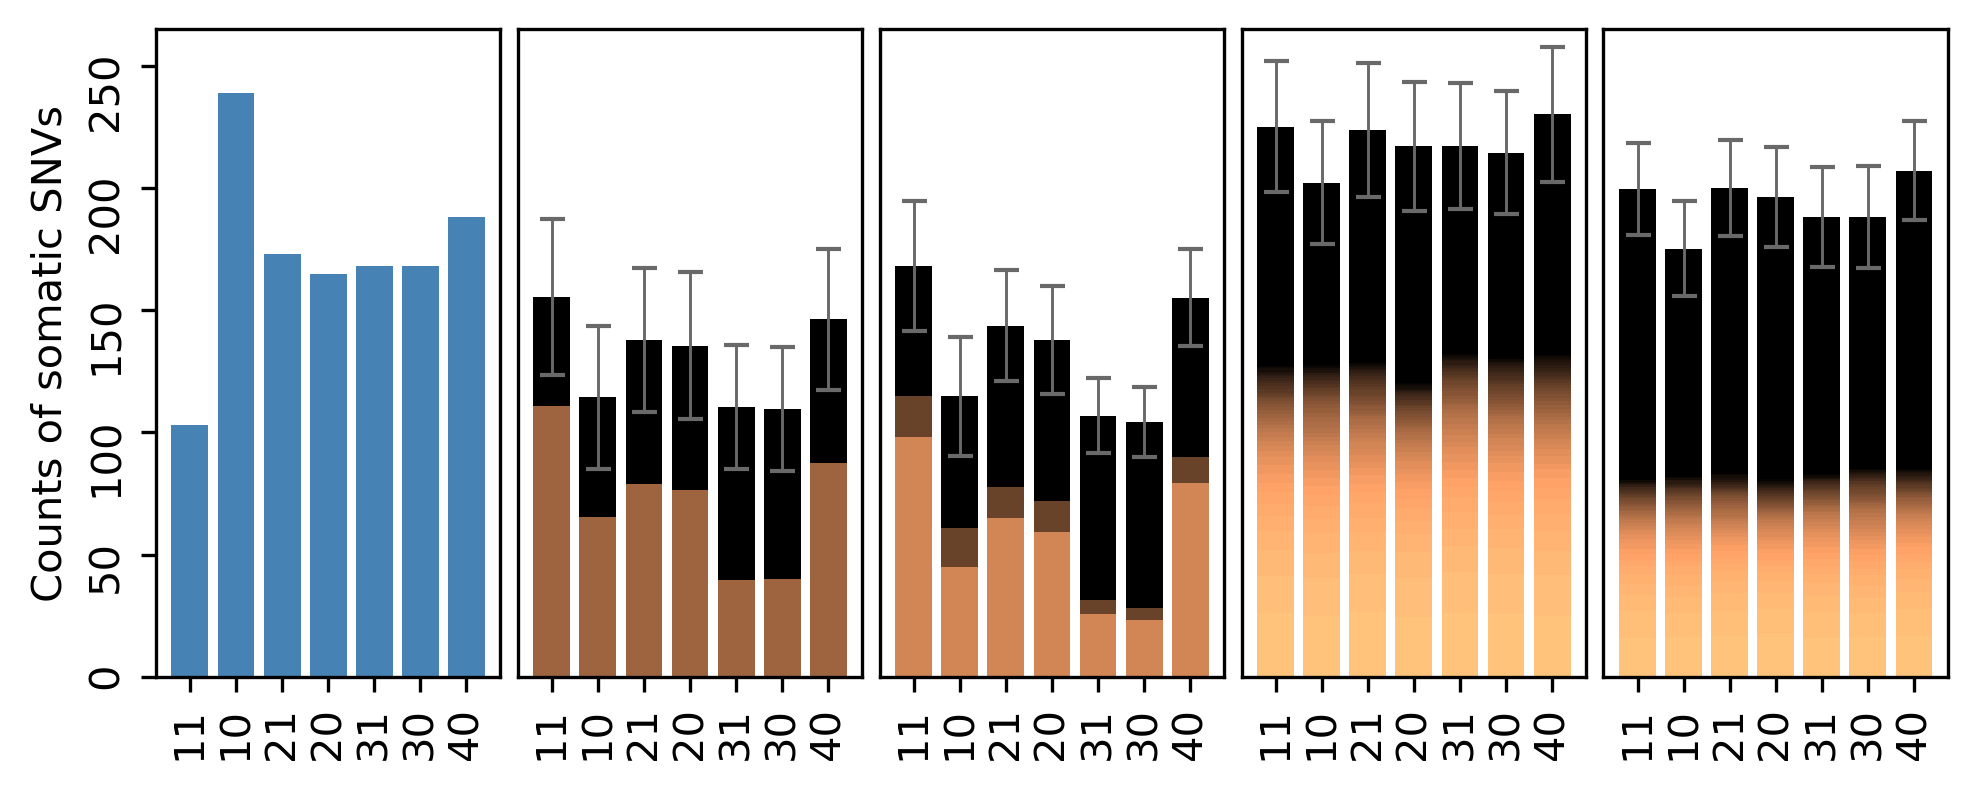

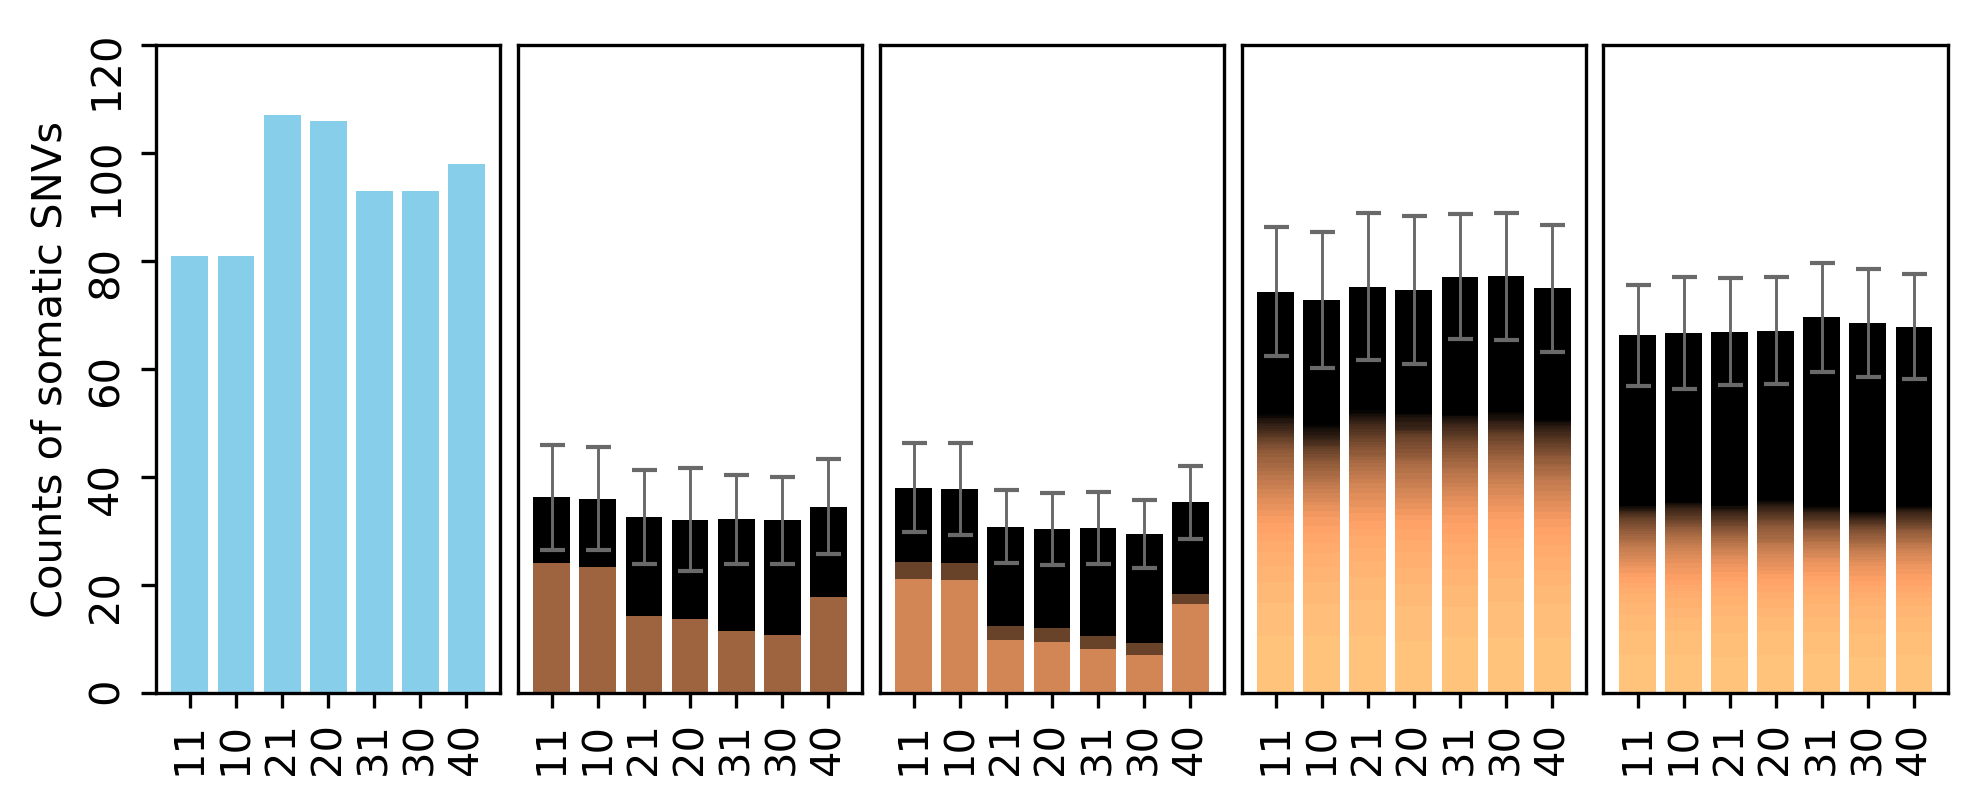

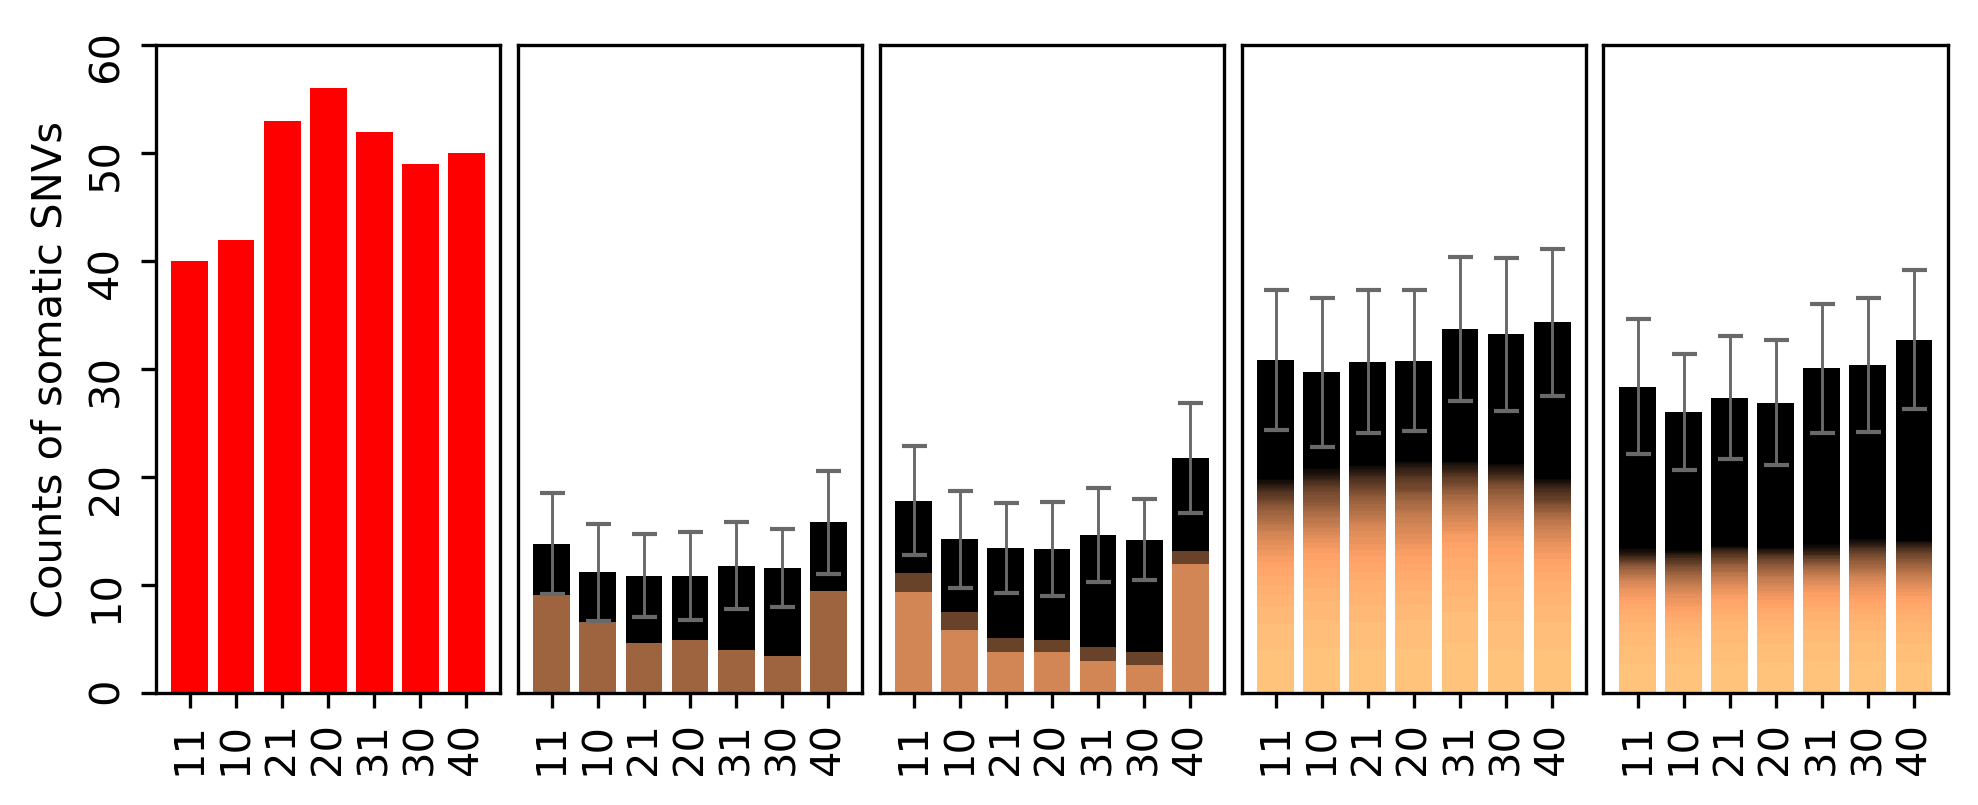

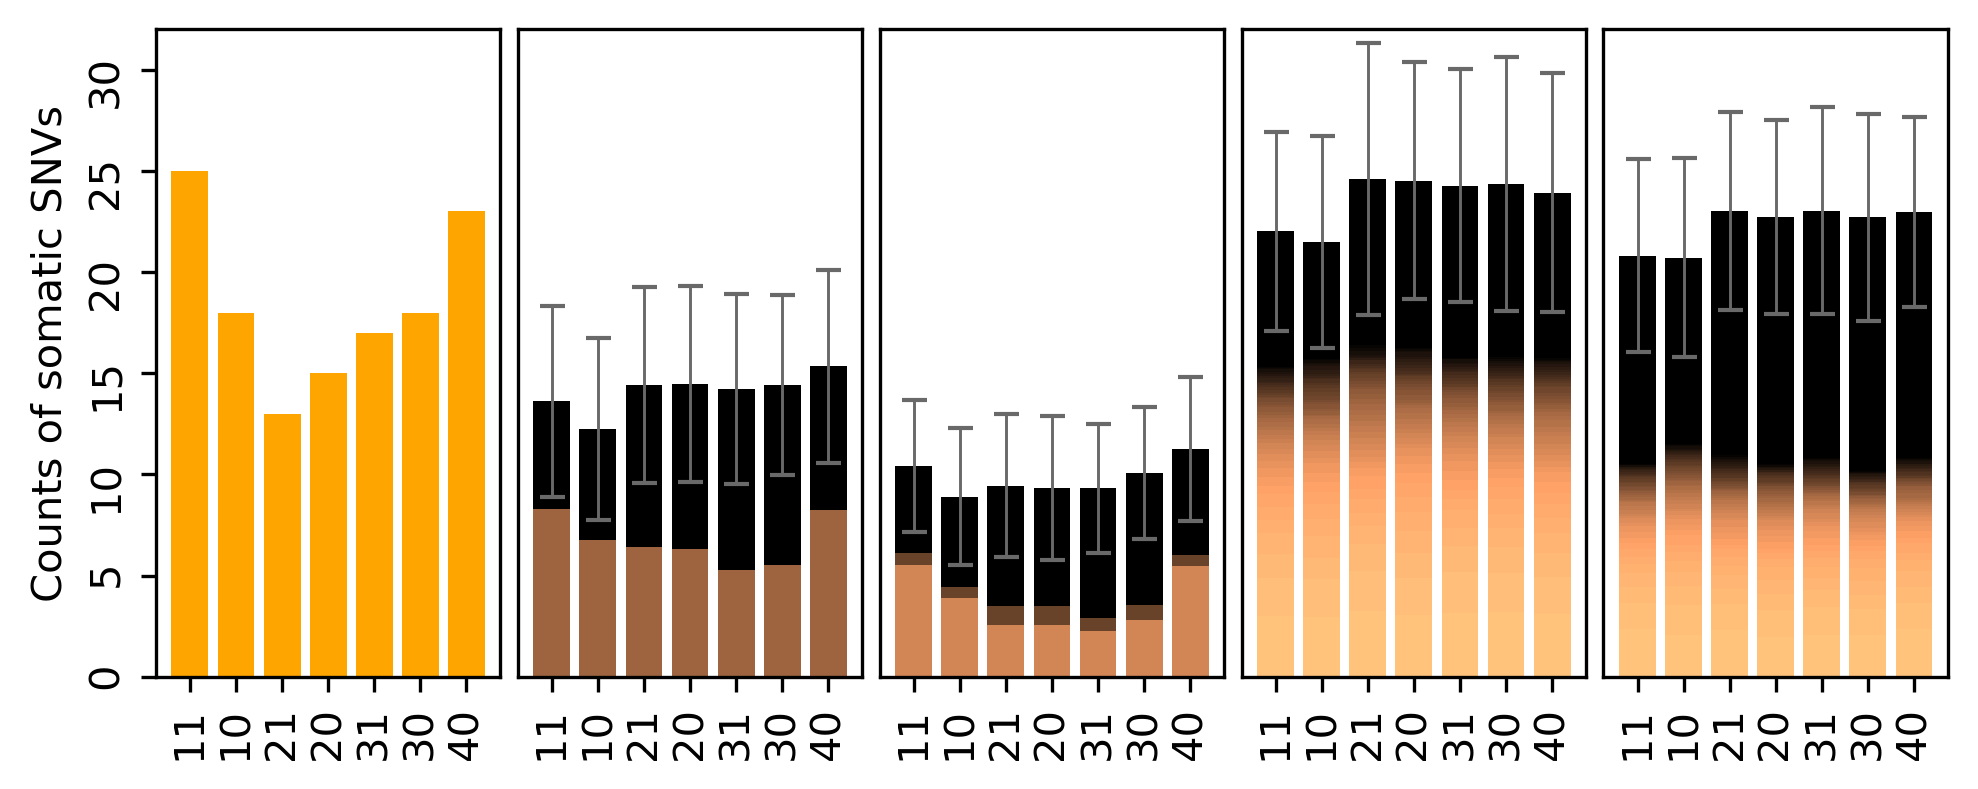

In [16]:
# Plotting
ylim_dict2 = {'S1':265, 'S2':120, 'F1':60, 'F2':32}

for ind in ['S1', 'S2', 'F1', 'F2']:
    
    fig, ax = plt.subplots(1, 5, figsize=(3.50394*2.2, 3.50394*.8), dpi=300)
    
    # Observation -----------------------------------------------------
    # Loading data
    if ind == 'S1':
        path_id = 'Slaevis_ID1'
    elif ind == 'S2':
        path_id = 'Slaevis_ID2'
    elif ind == 'F1':
        path_id = 'Sleprosula_ID1'
    elif ind == 'F2':
        path_id = 'Sleprosula_ID2'
      
    with open('/Users/soutomimoto/Desktop/mathbio2019/apical_meristem_IV/data/'+ path_id +'_1209.csv') as pre_data_tree:
        reader = csv.reader(pre_data_tree)
        data_tree = [row for row in reader]
    
    # Converting to mutation matrix
    mut_M = []
    count_homo = 0
    for i in data_tree[1:]: # eliminating column names
        
        if ('0/0' in i)and('1/1' in i):# eliminating homo to homo mutation
            #print(i)
            count_homo+=1
        else:
            row_M = []
            for j in i[1:]:
                if j != i[0]: # different from branch 0
                    row_M.append(1)
                elif j == i[0]: # same with branch 0
                    row_M.append(0)
            mut_M.append(copy.copy(row_M))

    obs_muts  = np.array(mut_M)
    # ------------------------------------------------------------------
    
    plt.subplot(1, 5, 1)
    plt.bar(br_ID, [np.sum(i) for i in obs_muts.T], color=colordict[ind])
    
    plt.ylim(0, ylim_dict2[ind])
    plt.tick_params(axis='x', labelsize=10, labelrotation=90)
    plt.tick_params(axis='y', labelsize=10, labelrotation=90)
    plt.ylabel('Counts of somatic SNVs')
    
    # For model predictions
    for ct_m, model in enumerate(['Model1.0', 'Model2.0', 'Model3.0', 'Model4.0']):

        # Parameters and Pred. ---------------------------------------
        NumStem, _, _ = model_paras[model+'_'+ind]
        Ave_mutFreqAtBranch, SE_mutFreqAtBranch = mut_hist_func(NumStem, sim_results[model+'_'+ind]) # Pred.
        pred_muts = Ave_mutFreqAtBranch

        # Plotting -----------------------------------------
        plt.subplot(1, 5, ct_m+2)
        labeList = [str(k)+'/'+str(len(pred_muts[0])) for k in range(1,len(pred_muts[0])+1)] # len(pred_muts[0]) = NumStem
        
        bottom_data = np.zeros(numBranch)
        for kcut, k in enumerate(pred_muts.T):
            plt.bar([i for i in br_ID], k, bottom=bottom_data, label=labeList[kcut],
                    color=cm.copper(1-(kcut+1)/len(pred_muts[0]))) # stackplot
            
            bottom_data += k
            
            if kcut+1 == len(pred_muts[0]): # last
                plt.errorbar([i for i in br_ID], bottom_data, yerr= SE_mutFreqAtBranch, 
                             ecolor="dimgrey", elinewidth=0.7, capsize=3, linestyle="None")        

        plt.yticks([])
        plt.ylim(0, ylim_dict2[ind])
        plt.tick_params(axis='x', labelsize=10, labelrotation=90)
        
    plt.ylim(0, ylim_dict2[ind])
    plt.subplots_adjust(wspace=0.05)
    plt.show()